In [127]:
import pandas as pd


In [128]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [129]:
df.shape

(7043, 21)

In [130]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [131]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [132]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [133]:
df['TotalCharges'].str.strip().eq('').sum()

np.int64(11)

In [134]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [135]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [136]:
df = df.dropna(subset=['TotalCharges'])

In [137]:
df.shape

(7032, 21)

In [138]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

In [139]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [140]:
df['Churn'].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [141]:
df['Churn'].value_counts(normalize=True) * 100

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

In [142]:
pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


In [143]:
pd.crosstab(df['InternetService'], df['Churn'], normalize='index') * 100

Churn,No,Yes
InternetService,,
DSL,81.001656,18.998344
Fiber optic,58.107235,41.892765
No,92.565789,7.434211


In [144]:
pd.crosstab(df['SeniorCitizen'], df['Churn'], normalize='index') * 100

Churn,No,Yes
SeniorCitizen,,
0,76.349745,23.650255
1,58.318739,41.681261


In [145]:
pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index') * 100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.268482,16.731518
Credit card (automatic),84.746877,15.253123
Electronic check,54.714588,45.285412
Mailed check,80.798005,19.201995


In [146]:
pd.crosstab(df['gender'], df['Churn'], normalize='index') * 100

Churn,No,Yes
gender,,
Female,73.040482,26.959518
Male,73.795435,26.204565


In [147]:
pd.crosstab(df['tenure'], df['Churn'], normalize='index') * 100

Churn,No,Yes
tenure,,
1,38.009788,61.990212
2,48.319328,51.680672
3,53.000000,47.000000
4,52.840909,47.159091
5,51.879699,48.120301
...,...,...
68,91.000000,9.000000
69,91.578947,8.421053
70,90.756303,9.243697


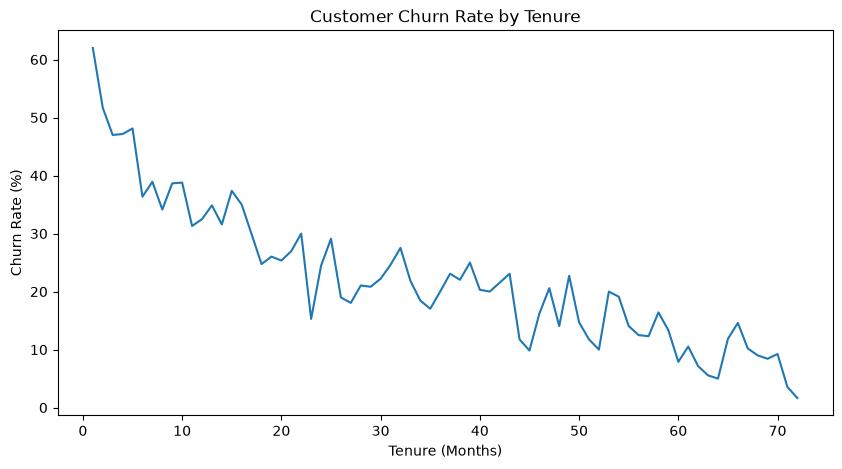

In [148]:
import matplotlib.pyplot as plt

churn_by_tenure = df.groupby('tenure')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
)

plt.figure(figsize=(10, 5))
plt.plot(churn_by_tenure.index, churn_by_tenure.values)
plt.xlabel('Tenure (Months)')
plt.ylabel('Churn Rate (%)')
plt.title('Customer Churn Rate by Tenure')
plt.show()

In [149]:
pd.crosstab(
    pd.cut(df['MonthlyCharges'], bins=5),
    df['Churn'],
    normalize='index'
) * 100

Churn,No,Yes
MonthlyCharges,,
"(18.15, 38.35]",88.553881,11.446119
"(38.35, 58.45]",72.981057,27.018943
"(58.45, 78.55]",70.476190,29.523810
"(78.55, 98.65]",63.013699,36.986301
"(98.65, 118.75]",69.942748,30.057252


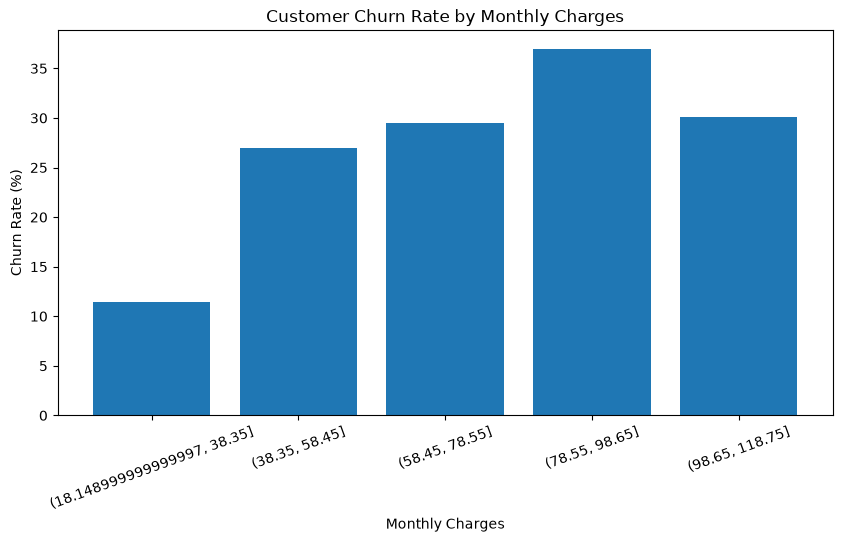

In [150]:
churn_by_charges = df.groupby(
    pd.cut(df['MonthlyCharges'], bins=5, include_lowest=True)
)['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)

plt.figure(figsize=(10, 5))
plt.bar(churn_by_charges.index.astype(str), churn_by_charges.values)
plt.xlabel('Monthly Charges')
plt.ylabel('Churn Rate (%)')
plt.title('Customer Churn Rate by Monthly Charges')
plt.xticks(rotation=20)
plt.show()

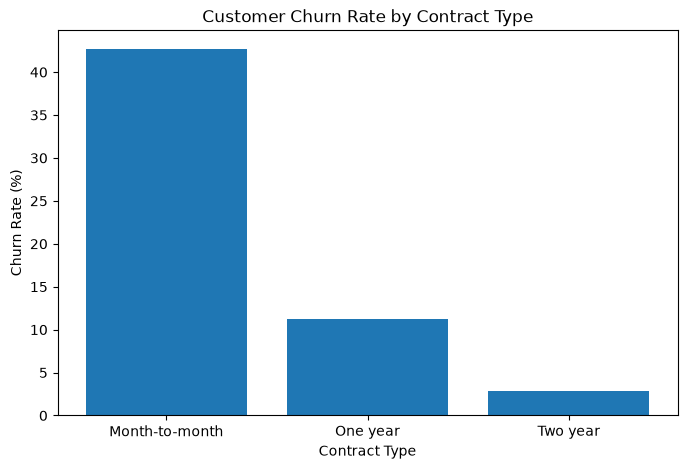

In [151]:
churn_by_contract = pd.crosstab(
    df['Contract'],
    df['Churn'],
    normalize='index'
)['Yes'] * 100

plt.figure(figsize=(8, 5))
plt.bar(churn_by_contract.index, churn_by_contract.values)
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')
plt.title('Customer Churn Rate by Contract Type')
plt.show()

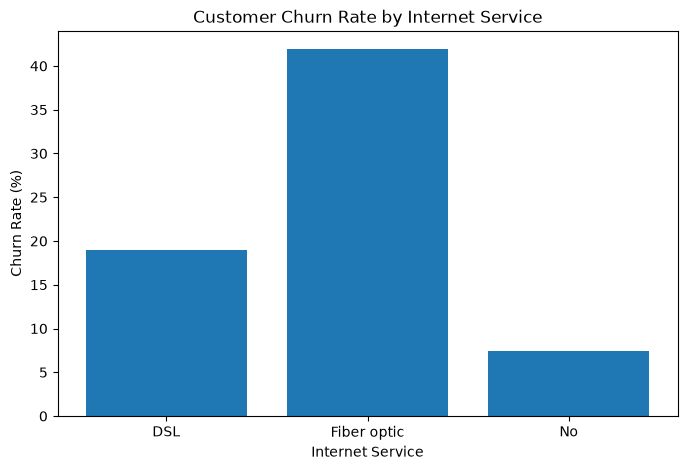

In [152]:
churn_by_internet = pd.crosstab(
    df['InternetService'],
    df['Churn'],
    normalize='index'
)['Yes'] * 100

plt.figure(figsize=(8, 5))
plt.bar(churn_by_internet.index, churn_by_internet.values)
plt.xlabel('Internet Service')
plt.ylabel('Churn Rate (%)')
plt.title('Customer Churn Rate by Internet Service')
plt.show()

In [153]:
churn_by_senior = pd.crosstab(
    df['SeniorCitizen'],
    df['Churn'],
    normalize='index'
) * 100

churn_by_senior

Churn,No,Yes
SeniorCitizen,,
0,76.349745,23.650255
1,58.318739,41.681261


In [154]:
churn_by_charges = pd.crosstab(
    pd.cut(df['MonthlyCharges'], bins=5),
    df['Churn'],
    normalize='index'
) * 100

churn_by_charges

Churn,No,Yes
MonthlyCharges,,
"(18.15, 38.35]",88.553881,11.446119
"(38.35, 58.45]",72.981057,27.018943
"(58.45, 78.55]",70.476190,29.523810
"(78.55, 98.65]",63.013699,36.986301
"(98.65, 118.75]",69.942748,30.057252


In [155]:
churn_by_payment = pd.crosstab(
    df['PaymentMethod'],
    df['Churn'],
    normalize='index'
) * 100

churn_by_payment


Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.268482,16.731518
Credit card (automatic),84.746877,15.253123
Electronic check,54.714588,45.285412
Mailed check,80.798005,19.201995


In [156]:
pd.crosstab(
    df['Contract'],
    df['Churn'],
    normalize='index'
) * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


In [157]:
churn_by_payment = pd.crosstab(
    df['PaymentMethod'],
    df['Churn'],
    normalize='index'
) * 100

churn_by_payment

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.268482,16.731518
Credit card (automatic),84.746877,15.253123
Electronic check,54.714588,45.285412
Mailed check,80.798005,19.201995


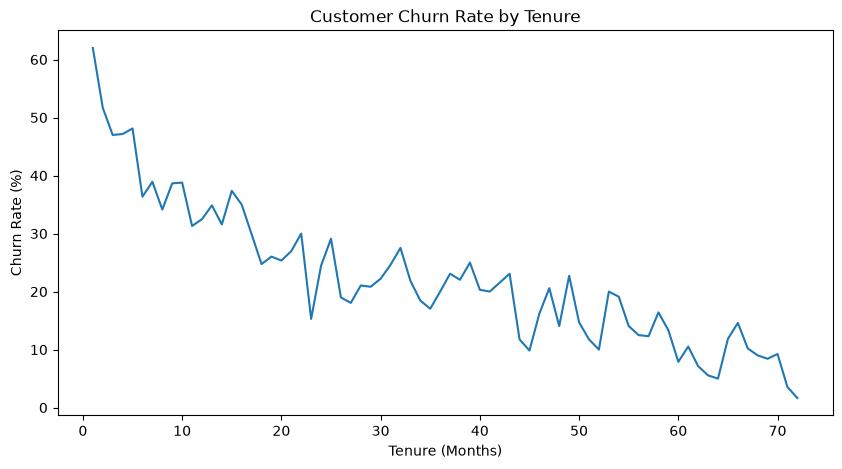

In [158]:
import matplotlib.pyplot as plt

churn_by_tenure = df.groupby('tenure')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
)

plt.figure(figsize=(10, 5))
plt.plot(churn_by_tenure.index, churn_by_tenure.values)
plt.xlabel('Tenure (Months)')
plt.ylabel('Churn Rate (%)')
plt.title('Customer Churn Rate by Tenure')
plt.show()

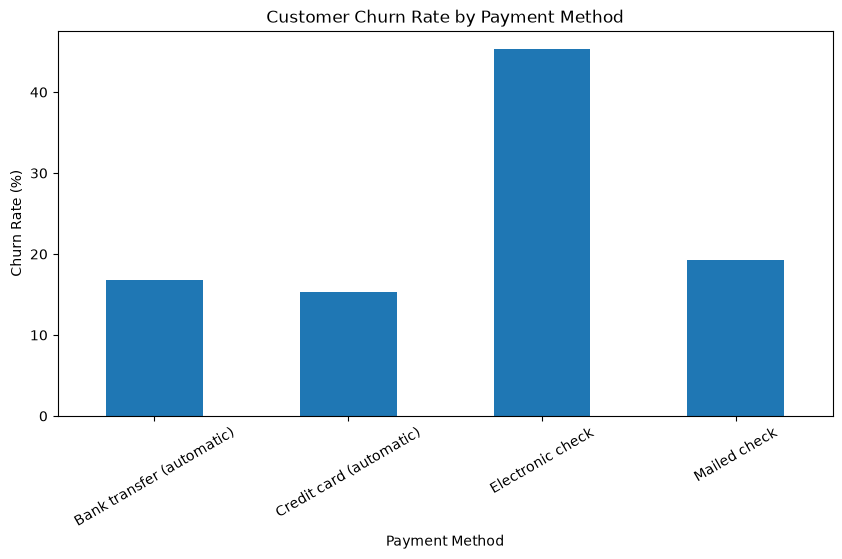

In [159]:
churn_by_payment = pd.crosstab(
    df['PaymentMethod'],
    df['Churn'],
    normalize='index'
) * 100

churn_by_payment['Yes'].plot(kind='bar', figsize=(10, 5))

plt.xlabel('Payment Method')
plt.ylabel('Churn Rate (%)')
plt.title('Customer Churn Rate by Payment Method')
plt.xticks(rotation=30)
plt.show()

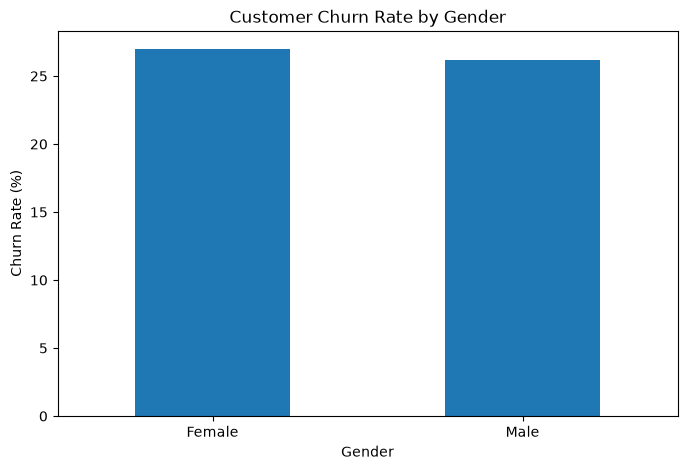

In [160]:
churn_by_gender = pd.crosstab(
    df['gender'],
    df['Churn'],
    normalize='index'
) * 100

churn_by_gender['Yes'].plot(kind='bar', figsize=(8, 5))

plt.xlabel('Gender')
plt.ylabel('Churn Rate (%)')
plt.title('Customer Churn Rate by Gender')
plt.xticks(rotation=0)
plt.show()

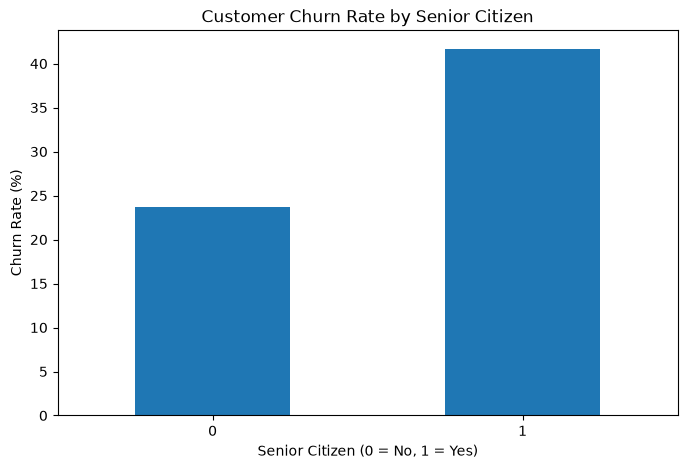

In [161]:
churn_by_senior = pd.crosstab(
    df['SeniorCitizen'],
    df['Churn'],
    normalize='index'
) * 100

churn_by_senior['Yes'].plot(kind='bar', figsize=(8, 5))

plt.xlabel('Senior Citizen (0 = No, 1 = Yes)')
plt.ylabel('Churn Rate (%)')
plt.title('Customer Churn Rate by Senior Citizen')
plt.xticks(rotation=0)
plt.show()

In [162]:
df = df.drop('customerID', axis=1)

In [163]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [164]:
if 'customerID' in df.columns:
    df = df.drop('customerID', axis=1)

print("Customer ID column handled successfully!")

Customer ID column handled successfully!


In [165]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [166]:
y = df['Churn'].map({'No': 0, 'Yes': 1})

X = df.drop('Churn', axis=1)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7032, 19)
y shape: (7032,)


In [167]:
import numpy as np

# Create a reproducible random split
np.random.seed(42)

indices = np.random.permutation(len(X))

split_point = int(len(X) * 0.8)

train_indices = indices[:split_point]
test_indices = indices[split_point:]

X_train = X.iloc[train_indices]
X_test = X.iloc[test_indices]

y_train = y.iloc[train_indices]
y_test = y.iloc[test_indices]

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (5625, 19)
Testing data: (1407, 19)


In [168]:
categorical_columns = X.select_dtypes(
    include='object'
).columns

numerical_columns = X.select_dtypes(
    exclude='object'
).columns

print("Categorical columns:")
print(categorical_columns)

print("\nNumerical columns:")
print(numerical_columns)

Categorical columns:
Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='str')

Numerical columns:
Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='str')


C:\Users\vishn\AppData\Local\Temp\ipykernel_15164\3895467331.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X.select_dtypes(


In [169]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

encoder = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            'categorical',
            encoder,
            categorical_columns
        ),
        (
            'numerical',
            'passthrough',
            numerical_columns
        )
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [170]:
categorical_columns = X.select_dtypes(include='object').columns

numerical_columns = X.select_dtypes(exclude='object').columns

print("Categorical columns:")
print(categorical_columns)

print("\nNumerical columns:")
print(numerical_columns)

Categorical columns:
Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='str')

Numerical columns:
Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='str')


C:\Users\vishn\AppData\Local\Temp\ipykernel_15164\3120214479.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X.select_dtypes(include='object').columns


In [171]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

print("Encoder is ready!")

Encoder is ready!


In [172]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('categorical', encoder, categorical_columns),
        ('numerical', 'passthrough', numerical_columns)
    ]
)

print("Preprocessor is ready!")

Preprocessor is ready!


In [173]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Training data after processing:", X_train_processed.shape)
print("Testing data after processing:", X_test_processed.shape)

Training data after processing: (5625, 45)
Testing data after processing: (1407, 45)


In [174]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

print("Model is ready!")

Model is ready!


In [175]:
model.fit(X_train_processed, y_train)

print("Model training completed!")

Model training completed!


c:\Users\vishn\Desktop\python_learning\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [176]:
model.fit(X_train_processed, y_train)

print("Model training completed!")

Model training completed!


c:\Users\vishn\Desktop\python_learning\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [177]:
y_pred = model.predict(X_test_processed)

print("Predictions completed!")

Predictions completed!


In [178]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)
print("Model Accuracy (%):", accuracy * 100)

Model Accuracy: 0.820184790334044
Model Accuracy (%): 82.0184790334044


In [179]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.91      0.88      1017
           1       0.71      0.60      0.65       390

    accuracy                           0.82      1407
   macro avg       0.78      0.75      0.76      1407
weighted avg       0.81      0.82      0.82      1407



In [180]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[921  96]
 [157 233]]


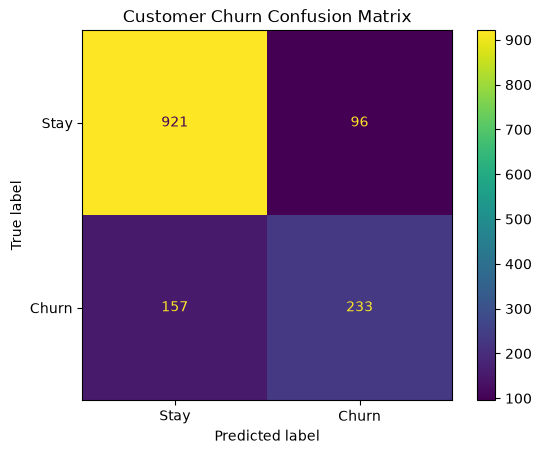

In [181]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Stay', 'Churn']
)

disp.plot()
plt.title('Customer Churn Confusion Matrix')
plt.show()

In [182]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

print("Random Forest model is ready!")

ImportError: DLL load failed while importing _partitioner: An Application Control policy has blocked this file.

In [183]:
balanced_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

print("Balanced Logistic Regression model is ready!")

Balanced Logistic Regression model is ready!


In [ ]:
balanced_model.fit(X_train_processed, y_train)

print("Balanced model training completed!")

Balanced model training completed!


c:\Users\vishn\Desktop\python_learning\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
y_pred_balanced = balanced_model.predict(X_test_processed)

print("Balanced model predictions completed!")

Balanced model predictions completed!


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_balanced))

              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1033
           1       0.50      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.73      0.75      1407



In [ ]:
cm_balanced = confusion_matrix(y_test, y_pred_balanced)

print(cm_balanced)

[[733 300]
 [ 76 298]]


In [ ]:
churn_probability = balanced_model.predict_proba(X_test_processed)[:, 1]

print(churn_probability[:10])

[0.01551145 0.27755374 0.85836456 0.27427625 0.59654976 0.68944964
 0.3039643  0.89555847 0.43813079 0.05563138]


In [ ]:
risk_df = X_test.copy()

risk_df['Churn_Probability'] = churn_probability

risk_df['Churn_Risk_Percent'] = risk_df['Churn_Probability'] * 100

risk_df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn_Probability,Churn_Risk_Percent
2481,Male,1,Yes,No,61,Yes,Yes,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),25.00,1501.75,0.015511,1.551145
6784,Female,0,No,No,19,Yes,Yes,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,Month-to-month,No,Bank transfer (automatic),24.70,465.85,0.277554,27.755374
6125,Male,0,Yes,No,13,Yes,Yes,Fiber optic,No,No,...,No,Yes,Yes,Month-to-month,Yes,Credit card (automatic),102.25,1359.00,0.858365,85.836456
3052,Male,0,Yes,No,37,Yes,Yes,DSL,Yes,No,...,No,No,No,Month-to-month,Yes,Mailed check,55.05,2030.75,0.274276,27.427625
4099,Female,0,No,No,6,No,No phone service,DSL,Yes,No,...,No,No,No,Month-to-month,No,Bank transfer (automatic),29.45,161.45,0.596550,59.654976


In [ ]:
high_risk_customers = risk_df.sort_values(
    'Churn_Probability',
    ascending=False
)

high_risk_customers.head(10)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn_Probability,Churn_Risk_Percent
1976,Male,1,No,No,1,Yes,Yes,Fiber optic,No,No,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,93.55,93.55,0.936086,93.608630
6368,Male,1,No,No,2,Yes,Yes,Fiber optic,No,No,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,94.00,181.70,0.934401,93.440121
3159,Male,1,No,No,3,Yes,Yes,Fiber optic,No,No,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,94.85,335.75,0.934042,93.404215
997,Female,1,No,No,4,Yes,Yes,Fiber optic,No,No,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,94.30,424.45,0.933693,93.369268
5783,Female,1,No,No,1,Yes,No,Fiber optic,No,No,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,89.30,89.30,0.926291,92.629051
5933,Male,1,No,No,3,Yes,Yes,Fiber optic,No,Yes,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,105.00,294.45,0.923232,92.323160
2577,Female,0,No,No,1,Yes,Yes,Fiber optic,No,No,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,94.60,94.60,0.921755,92.175533
1148,Female,0,No,No,2,Yes,Yes,Fiber optic,No,No,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,95.15,196.90,0.920077,92.007677
3346,Female,1,No,No,2,Yes,Yes,Fiber optic,No,No,...,No,No,Yes,Month-to-month,Yes,Electronic check,84.05,186.05,0.919800,91.980000
4618,Male,1,No,No,4,Yes,No,Fiber optic,No,No,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,94.75,422.40,0.917327,91.732674


In [ ]:
def risk_category(probability):
    if probability < 0.30:
        return 'Low Risk'
    elif probability < 0.60:
        return 'Medium Risk'
    else:
        return 'High Risk'


high_risk_customers['Risk_Category'] = high_risk_customers['Churn_Probability'].apply(
    risk_category
)

high_risk_customers.head(10)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn_Probability,Churn_Risk_Percent,Risk_Category
1976,Male,1,No,No,1,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,93.55,93.55,0.936086,93.608630,High Risk
6368,Male,1,No,No,2,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,94.00,181.70,0.934401,93.440121,High Risk
3159,Male,1,No,No,3,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,94.85,335.75,0.934042,93.404215,High Risk
997,Female,1,No,No,4,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,94.30,424.45,0.933693,93.369268,High Risk
5783,Female,1,No,No,1,Yes,No,Fiber optic,No,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,89.30,89.30,0.926291,92.629051,High Risk
5933,Male,1,No,No,3,Yes,Yes,Fiber optic,No,Yes,...,Yes,Yes,Month-to-month,Yes,Electronic check,105.00,294.45,0.923232,92.323160,High Risk
2577,Female,0,No,No,1,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,94.60,94.60,0.921755,92.175533,High Risk
1148,Female,0,No,No,2,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,95.15,196.90,0.920077,92.007677,High Risk
3346,Female,1,No,No,2,Yes,Yes,Fiber optic,No,No,...,No,Yes,Month-to-month,Yes,Electronic check,84.05,186.05,0.919800,91.980000,High Risk
4618,Male,1,No,No,4,Yes,No,Fiber optic,No,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,94.75,422.40,0.917327,91.732674,High Risk


In [ ]:
risk_summary = high_risk_customers['Risk_Category'].value_counts()

print(risk_summary)

Risk_Category
Low Risk       593
High Risk      492
Medium Risk    322
Name: count, dtype: int64


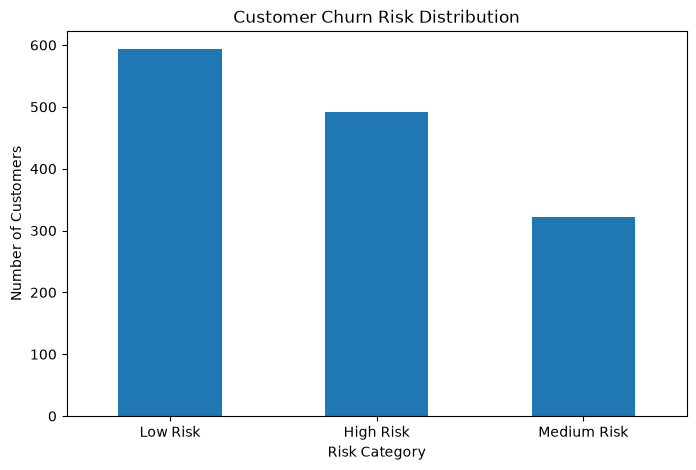

In [ ]:
risk_summary.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.xlabel('Risk Category')
plt.ylabel('Number of Customers')
plt.title('Customer Churn Risk Distribution')
plt.xticks(rotation=0)
plt.show()

In [ ]:
top_risk_customers = high_risk_customers[
    [
        'tenure',
        'Contract',
        'InternetService',
        'MonthlyCharges',
        'TotalCharges',
        'PaymentMethod',
        'Churn_Probability',
        'Churn_Risk_Percent',
        'Risk_Category'
    ]
].head(20)

top_risk_customers

,tenure,Contract,InternetService,MonthlyCharges,TotalCharges,PaymentMethod,Churn_Probability,Churn_Risk_Percent,Risk_Category
1976,1,Month-to-month,Fiber optic,93.55,93.55,Electronic check,0.936086,93.608630,High Risk
6368,2,Month-to-month,Fiber optic,94.00,181.70,Electronic check,0.934401,93.440121,High Risk
3159,3,Month-to-month,Fiber optic,94.85,335.75,Electronic check,0.934042,93.404215,High Risk
997,4,Month-to-month,Fiber optic,94.30,424.45,Electronic check,0.933693,93.369268,High Risk
5783,1,Month-to-month,Fiber optic,89.30,89.30,Electronic check,0.926291,92.629051,High Risk
5933,3,Month-to-month,Fiber optic,105.00,294.45,Electronic check,0.923232,92.323160,High Risk
2577,1,Month-to-month,Fiber optic,94.60,94.60,Electronic check,0.921755,92.175533,High Risk
1148,2,Month-to-month,Fiber optic,95.15,196.90,Electronic check,0.920077,92.007677,High Risk
3346,2,Month-to-month,Fiber optic,84.05,186.05,Electronic check,0.919800,91.980000,High Risk
4618,4,Month-to-month,Fiber optic,94.75,422.40,Electronic check,0.917327,91.732674,High Risk


In [ ]:
risk_analysis = high_risk_customers.groupby('Risk_Category').agg({
    'tenure': 'mean',
    'MonthlyCharges': 'mean',
    'TotalCharges': 'mean'
})

risk_analysis

,tenure,MonthlyCharges,TotalCharges
Risk_Category,,,
High Risk,15.252033,77.141870,1345.981402
Low Risk,49.568297,55.457420,3065.993255
Medium Risk,28.590062,64.900311,2413.802640


In [ ]:
print(risk_analysis.round(2))

               tenure  MonthlyCharges  TotalCharges
Risk_Category                                      
High Risk       15.25           77.14       1345.98
Low Risk        49.57           55.46       3065.99
Medium Risk     28.59           64.90       2413.80


In [ ]:
contract_risk = pd.crosstab(
    high_risk_customers['Contract'],
    high_risk_customers['Risk_Category'],
    normalize='index'
) * 100

print(contract_risk.round(2))

Risk_Category   High Risk  Low Risk  Medium Risk
Contract                                        
Month-to-month      61.42      8.63        29.95
One year             2.85     69.75        27.40
Two year             0.00     97.34         2.66


In [ ]:
internet_risk = pd.crosstab(
    high_risk_customers['InternetService'],
    high_risk_customers['Risk_Category'],
    normalize='index'
) * 100

print(internet_risk.round(2))

Risk_Category    High Risk  Low Risk  Medium Risk
InternetService                                  
DSL                  23.99     52.42        23.59
Fiber optic          59.78     17.63        22.60
No                    0.00     77.70        22.30


In [ ]:
import sklearn

print("scikit-learn version:", sklearn.__version__)

scikit-learn version: 1.9.1


In [ ]:
# Create input data (X) and target (y)

y = df['Churn'].map({
    'No': 0,
    'Yes': 1
})

X = df.drop('Churn', axis=1)

print("X and y created successfully!")
print("X shape:", X.shape)
print("y shape:", y.shape)

X and y created successfully!
X shape: (7032, 19)
y shape: (7032,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (5625, 19)
Testing data: (1407, 19)


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Find categorical and numerical columns
categorical_columns = X_train.select_dtypes(include='object').columns
numerical_columns = X_train.select_dtypes(exclude='object').columns

# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical_columns),
        ('numerical', 'passthrough', numerical_columns)
    ]
)

# Convert the data into numbers
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Data preprocessing completed!")
print("Training data:", X_train_processed.shape)
print("Testing data:", X_test_processed.shape)

Data preprocessing completed!
Training data: (5625, 45)
Testing data: (1407, 45)


C:\Users\vishn\AppData\Local\Temp\ipykernel_5176\4079929720.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X_train.select_dtypes(include='object').columns


In [ ]:
from sklearn.linear_model import LogisticRegression

balanced_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

balanced_model.fit(
    X_train_processed,
    y_train
)

print("Balanced model trained successfully!")


Balanced model trained successfully!


c:\Users\vishn\Desktop\python_learning\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
churn_probability = balanced_model.predict_proba(
    X_test_processed
)[:, 1]

print("Churn probabilities calculated!")
print(churn_probability[:10])

Churn probabilities calculated!
[0.01551145 0.27755374 0.85836456 0.27427625 0.59654976 0.68944964
 0.3039643  0.89555847 0.43813079 0.05563138]


In [ ]:
risk_df = X_test.copy()

risk_df['Churn_Probability'] = churn_probability

print("Risk table created successfully!")

risk_df.head()

Risk table created successfully!


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn_Probability
2481,Male,1,Yes,No,61,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),25.00,1501.75,0.015511
6784,Female,0,No,No,19,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Bank transfer (automatic),24.70,465.85,0.277554
6125,Male,0,Yes,No,13,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Credit card (automatic),102.25,1359.00,0.858365
3052,Male,0,Yes,No,37,Yes,Yes,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Mailed check,55.05,2030.75,0.274276
4099,Female,0,No,No,6,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,No,Bank transfer (automatic),29.45,161.45,0.596550


In [ ]:
def risk_category(probability):
    if probability >= 0.70:
        return "High Risk"
    elif probability >= 0.40:
        return "Medium Risk"
    else:
        return "Low Risk"


risk_df['Risk_Category'] = risk_df['Churn_Probability'].apply(risk_category)

risk_df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn_Probability,Risk_Category
2481,Male,1,Yes,No,61,Yes,Yes,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),25.00,1501.75,0.015511,Low Risk
6784,Female,0,No,No,19,Yes,Yes,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,Month-to-month,No,Bank transfer (automatic),24.70,465.85,0.277554,Low Risk
6125,Male,0,Yes,No,13,Yes,Yes,Fiber optic,No,No,...,No,Yes,Yes,Month-to-month,Yes,Credit card (automatic),102.25,1359.00,0.858365,High Risk
3052,Male,0,Yes,No,37,Yes,Yes,DSL,Yes,No,...,No,No,No,Month-to-month,Yes,Mailed check,55.05,2030.75,0.274276,Low Risk
4099,Female,0,No,No,6,No,No phone service,DSL,Yes,No,...,No,No,No,Month-to-month,No,Bank transfer (automatic),29.45,161.45,0.596550,Medium Risk


In [ ]:
risk_summary = risk_df['Risk_Category'].value_counts()

print(risk_summary)


Risk_Category
Low Risk       688
High Risk      361
Medium Risk    358
Name: count, dtype: int64


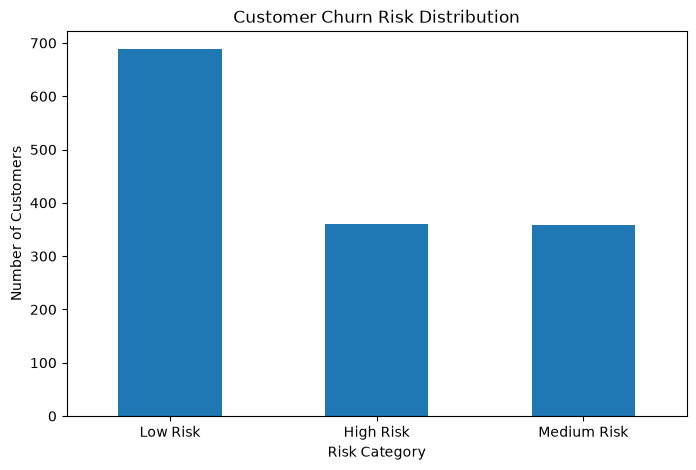

In [ ]:
risk_summary.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.xlabel('Risk Category')
plt.ylabel('Number of Customers')
plt.title('Customer Churn Risk Distribution')
plt.xticks(rotation=0)
plt.show()

In [ ]:
top_risk_customers = risk_df.sort_values(
    'Churn_Probability',
    ascending=False
)

top_risk_customers.head(10)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn_Probability,Risk_Category
1976,Male,1,No,No,1,Yes,Yes,Fiber optic,No,No,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,93.55,93.55,0.936086,High Risk
6368,Male,1,No,No,2,Yes,Yes,Fiber optic,No,No,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,94.00,181.70,0.934401,High Risk
3159,Male,1,No,No,3,Yes,Yes,Fiber optic,No,No,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,94.85,335.75,0.934042,High Risk
997,Female,1,No,No,4,Yes,Yes,Fiber optic,No,No,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,94.30,424.45,0.933693,High Risk
5783,Female,1,No,No,1,Yes,No,Fiber optic,No,No,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,89.30,89.30,0.926291,High Risk
5933,Male,1,No,No,3,Yes,Yes,Fiber optic,No,Yes,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,105.00,294.45,0.923232,High Risk
2577,Female,0,No,No,1,Yes,Yes,Fiber optic,No,No,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,94.60,94.60,0.921755,High Risk
1148,Female,0,No,No,2,Yes,Yes,Fiber optic,No,No,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,95.15,196.90,0.920077,High Risk
3346,Female,1,No,No,2,Yes,Yes,Fiber optic,No,No,...,No,No,Yes,Month-to-month,Yes,Electronic check,84.05,186.05,0.919800,High Risk
4618,Male,1,No,No,4,Yes,No,Fiber optic,No,No,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,94.75,422.40,0.917327,High Risk


In [ ]:
risk_df['customerID'] = df.loc[risk_df.index, 'customerID']

top_risk_customers = risk_df.sort_values(
    'Churn_Probability',
    ascending=False
)

top_risk_customers[
    ['customerID', 'Churn_Probability', 'Risk_Category']
].head(10)

KeyError: 'customerID'

In [ ]:
# Load the original dataset again
original_df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Convert TotalCharges to numeric
original_df['TotalCharges'] = pd.to_numeric(
    original_df['TotalCharges'],
    errors='coerce'
)

# Remove the same 11 rows with missing TotalCharges
original_df = original_df.dropna(subset=['TotalCharges'])

# Add customer IDs to our risk table
risk_df['customerID'] = original_df.loc[
    risk_df.index,
    'customerID'
]

# Show top 10 highest-risk customers
top_risk_customers = risk_df.sort_values(
    'Churn_Probability',
    ascending=False
)

top_risk_customers[
    ['customerID', 'Churn_Probability', 'Risk_Category']
].head(10)

,customerID,Churn_Probability,Risk_Category
1976,9497-QCMMS,0.936086,High Risk
6368,2720-WGKHP,0.934401,High Risk
3159,5150-ITWWB,0.934042,High Risk
997,1374-DMZUI,0.933693,High Risk
5783,1415-YFWLT,0.926291,High Risk
5933,6496-SLWHQ,0.923232,High Risk
2577,4910-GMJOT,0.921755,High Risk
1148,7851-WZEKY,0.920077,High Risk
3346,2545-EBUPK,0.919800,High Risk
4618,6350-XFYGW,0.917327,High Risk


In [ ]:
risk_df.to_csv(
    "customer_churn_risk_predictions.csv",
    index=False
)

print("Risk prediction file saved successfully!")

Risk prediction file saved successfully!


In [ ]:
risk_analysis = risk_df.groupby('Risk_Category').agg(
    Customers=('customerID', 'count'),
    Average_Churn_Probability=('Churn_Probability', 'mean')
)

risk_analysis['Average_Churn_Probability'] = (
    risk_analysis['Average_Churn_Probability'] * 100
)

print(risk_analysis.round(2))

               Customers  Average_Churn_Probability
Risk_Category                                      
High Risk            361                      80.91
Low Risk             688                      14.15
Medium Risk          358                      54.81


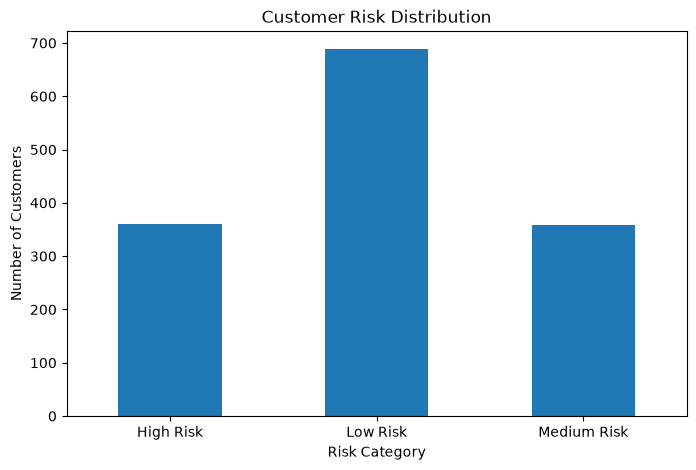

In [ ]:
risk_analysis['Customers'].plot(
    kind='bar',
    figsize=(8, 5)
)

plt.xlabel('Risk Category')
plt.ylabel('Number of Customers')
plt.title('Customer Risk Distribution')
plt.xticks(rotation=0)
plt.show()

In [ ]:
high_risk = risk_df[
    risk_df['Risk_Category'] == 'High Risk'
]

contract_risk = high_risk['Contract'].value_counts()

print(contract_risk)

Contract
Month-to-month    361
Name: count, dtype: int64


In [ ]:
payment_risk = high_risk['PaymentMethod'].value_counts()

print(payment_risk)

PaymentMethod
Electronic check             261
Bank transfer (automatic)     39
Mailed check                  33
Credit card (automatic)       28
Name: count, dtype: int64


In [ ]:
internet_risk = high_risk['InternetService'].value_counts()

print(internet_risk)

InternetService
Fiber optic    307
DSL             54
Name: count, dtype: int64


In [ ]:
tenure_risk = high_risk['tenure'].describe()

print(tenure_risk)

count    361.000000
mean      12.867036
std       12.932691
min        1.000000
25%        2.000000
50%        9.000000
75%       19.000000
max       68.000000
Name: tenure, dtype: float64


In [ ]:
# Select high-risk customers
high_risk_customers = risk_df[
    risk_df['Risk_Category'] == 'High Risk'
]

# Show the first 10 high-risk customers
high_risk_customers.head(10)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn_Probability,Risk_Category,customerID
6125,Male,0,Yes,No,13,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,Month-to-month,Yes,Credit card (automatic),102.25,1359.00,0.858365,High Risk,0871-URUWO
3469,Female,1,No,No,15,Yes,No,Fiber optic,No,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,91.50,1400.30,0.895558,High Risk,9402-ORRAH
2173,Male,0,No,No,4,Yes,No,Fiber optic,No,No,...,No,Yes,Month-to-month,No,Electronic check,86.05,308.10,0.838014,High Risk,2038-OEQZH
1291,Male,0,Yes,No,8,Yes,No,Fiber optic,Yes,No,...,No,No,Month-to-month,No,Electronic check,75.00,632.95,0.714900,High Risk,7993-PYKOF
3257,Male,0,No,No,22,Yes,No,Fiber optic,No,Yes,...,Yes,Yes,Month-to-month,Yes,Mailed check,93.20,2157.30,0.769550,High Risk,5482-VXSXJ
1976,Male,1,No,No,1,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,93.55,93.55,0.936086,High Risk,9497-QCMMS
5194,Male,0,No,Yes,22,Yes,No,Fiber optic,No,Yes,...,Yes,No,Month-to-month,Yes,Electronic check,89.40,2001.50,0.735173,High Risk,1902-XBTFB
1081,Male,1,Yes,No,46,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,98.85,4564.90,0.822406,High Risk,1751-NCDLI
4322,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,Month-to-month,Yes,Electronic check,70.15,123.80,0.851016,High Risk,7394-LWLYN
4154,Male,0,No,No,6,Yes,Yes,Fiber optic,No,No,...,No,No,Month-to-month,Yes,Electronic check,74.90,469.80,0.855182,High Risk,4229-CZMLL


In [ ]:
contract_risk = high_risk_customers['Contract'].value_counts()

print(contract_risk)

Contract
Month-to-month    361
Name: count, dtype: int64


In [ ]:
high_risk_report = high_risk_customers[
    [
        'customerID',
        'tenure',
        'MonthlyCharges',
        'TotalCharges',
        'Contract',
        'InternetService',
        'PaymentMethod',
        'Churn_Probability',
        'Risk_Category'
    ]
]

high_risk_report.head(10)

,customerID,tenure,MonthlyCharges,TotalCharges,Contract,InternetService,PaymentMethod,Churn_Probability,Risk_Category
6125,0871-URUWO,13,102.25,1359.00,Month-to-month,Fiber optic,Credit card (automatic),0.858365,High Risk
3469,9402-ORRAH,15,91.50,1400.30,Month-to-month,Fiber optic,Electronic check,0.895558,High Risk
2173,2038-OEQZH,4,86.05,308.10,Month-to-month,Fiber optic,Electronic check,0.838014,High Risk
1291,7993-PYKOF,8,75.00,632.95,Month-to-month,Fiber optic,Electronic check,0.714900,High Risk
3257,5482-VXSXJ,22,93.20,2157.30,Month-to-month,Fiber optic,Mailed check,0.769550,High Risk
1976,9497-QCMMS,1,93.55,93.55,Month-to-month,Fiber optic,Electronic check,0.936086,High Risk
5194,1902-XBTFB,22,89.40,2001.50,Month-to-month,Fiber optic,Electronic check,0.735173,High Risk
1081,1751-NCDLI,46,98.85,4564.90,Month-to-month,Fiber optic,Electronic check,0.822406,High Risk
4322,7394-LWLYN,2,70.15,123.80,Month-to-month,Fiber optic,Electronic check,0.851016,High Risk
4154,4229-CZMLL,6,74.90,469.80,Month-to-month,Fiber optic,Electronic check,0.855182,High Risk


In [ ]:
high_risk_report.to_csv(
    "high_risk_customers.csv",
    index=False
)

print("High-risk customer report saved successfully!")

High-risk customer report saved successfully!


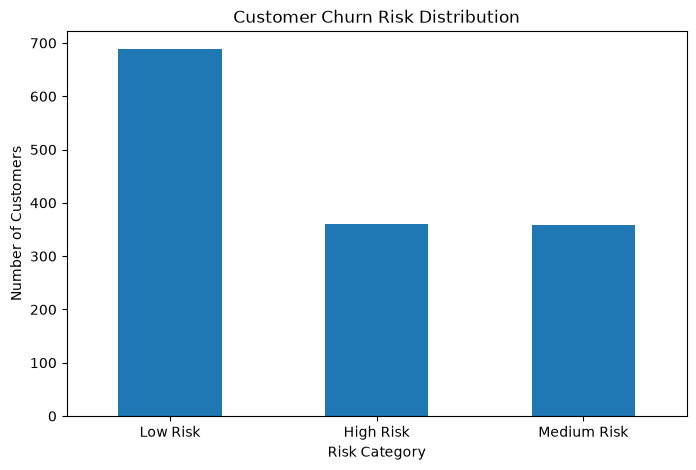

In [ ]:
risk_summary.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.xlabel('Risk Category')
plt.ylabel('Number of Customers')
plt.title('Customer Churn Risk Distribution')
plt.xticks(rotation=0)
plt.show()

In [ ]:
risk_insights = risk_df.groupby('Risk_Category').agg(
    Customers=('customerID', 'count'),
    Average_Tenure=('tenure', 'mean'),
    Average_Monthly_Charges=('MonthlyCharges', 'mean'),
    Average_Total_Charges=('TotalCharges', 'mean')
)

risk_insights.round(2)

,Customers,Average_Tenure,Average_Monthly_Charges,Average_Total_Charges
Risk_Category,,,,
High Risk,361,12.87,79.89,1136.47
Low Risk,688,47.41,57.09,3041.39
Medium Risk,358,24.70,65.98,2108.54


In [ ]:
risk_probability = risk_df.groupby('Risk_Category').agg(
    Average_Churn_Probability=('Churn_Probability', 'mean')
)

risk_probability['Average_Churn_Probability'] *= 100

risk_probability.round(2)

,Average_Churn_Probability
Risk_Category,
High Risk,80.91
Low Risk,14.15
Medium Risk,54.81


In [ ]:
high_risk_percentage = (
    (risk_df['Risk_Category'] == 'High Risk').mean() * 100
)

print(f"High-Risk Customers: {high_risk_percentage:.2f}%")

High-Risk Customers: 25.66%


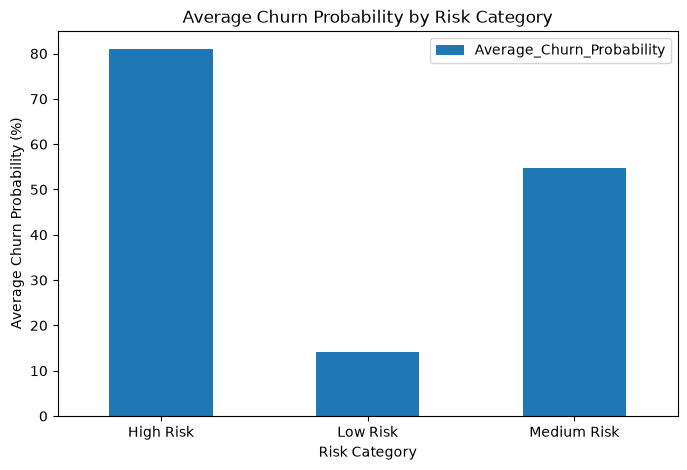

In [ ]:
risk_probability.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.xlabel('Risk Category')
plt.ylabel('Average Churn Probability (%)')
plt.title('Average Churn Probability by Risk Category')
plt.xticks(rotation=0)
plt.show()

In [ ]:
contract_churn = df.groupby('Contract')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
)

print(contract_churn.round(2))

Contract
Month-to-month    42.71
One year          11.28
Two year           2.85
Name: Churn, dtype: float64


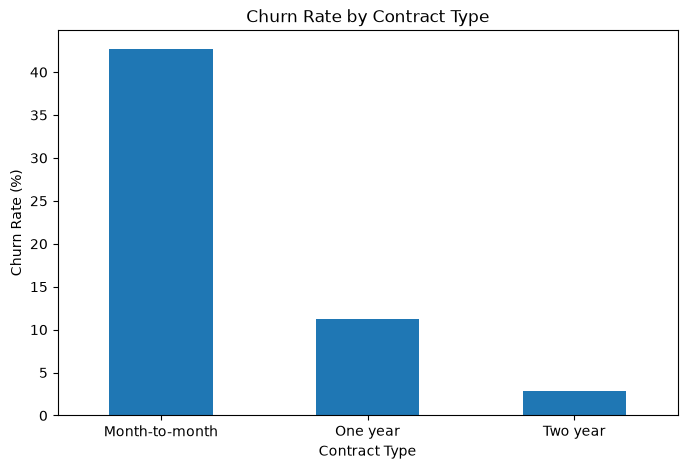

In [ ]:
contract_churn.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')
plt.title('Churn Rate by Contract Type')
plt.xticks(rotation=0)
plt.show()

In [ ]:
internet_churn = df.groupby('InternetService')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
)

print(internet_churn.round(2))

InternetService
DSL            19.00
Fiber optic    41.89
No              7.43
Name: Churn, dtype: float64


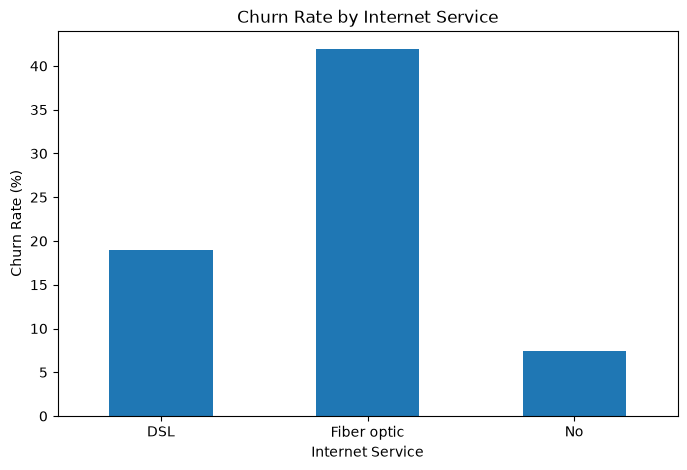

In [ ]:
internet_churn.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.xlabel('Internet Service')
plt.ylabel('Churn Rate (%)')
plt.title('Churn Rate by Internet Service')
plt.xticks(rotation=0)
plt.show()

In [ ]:
payment_churn = df.groupby('PaymentMethod')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
)

print(payment_churn.round(2))

PaymentMethod
Bank transfer (automatic)    16.73
Credit card (automatic)      15.25
Electronic check             45.29
Mailed check                 19.20
Name: Churn, dtype: float64


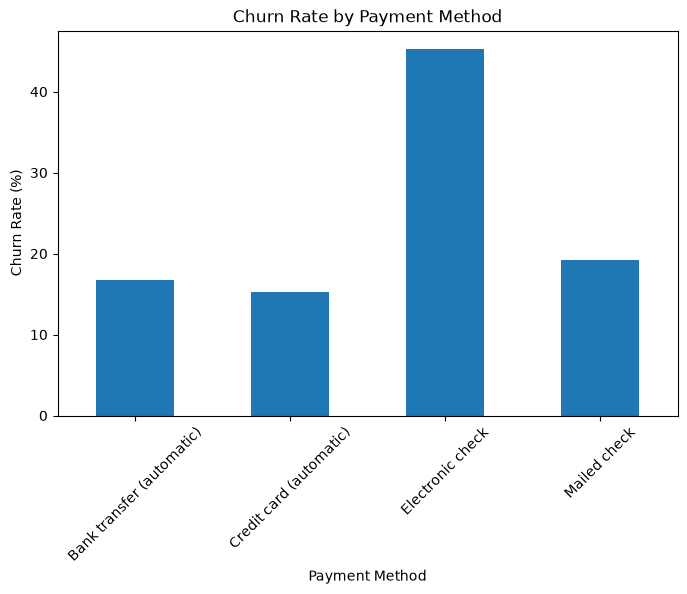

In [ ]:
payment_churn.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.xlabel('Payment Method')
plt.ylabel('Churn Rate (%)')
plt.title('Churn Rate by Payment Method')
plt.xticks(rotation=45)
plt.show()

In [ ]:
senior_churn = df.groupby('SeniorCitizen')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
)

print(senior_churn.round(2))

SeniorCitizen
0    23.65
1    41.68
Name: Churn, dtype: float64


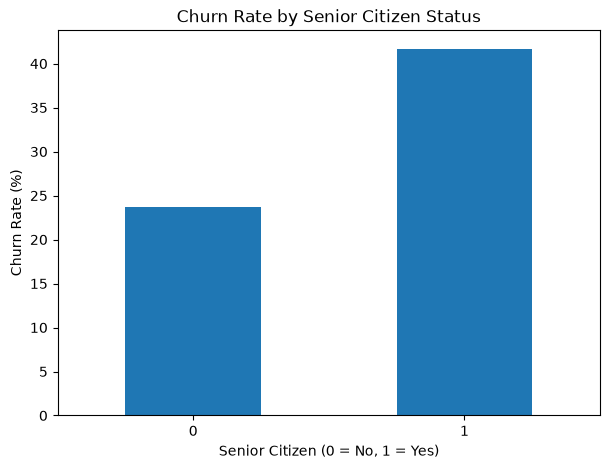

In [ ]:
senior_churn.plot(
    kind='bar',
    figsize=(7, 5)
)

plt.xlabel('Senior Citizen (0 = No, 1 = Yes)')
plt.ylabel('Churn Rate (%)')
plt.title('Churn Rate by Senior Citizen Status')
plt.xticks(rotation=0)
plt.show()

In [ ]:
tenure_churn = df.groupby('tenure')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
)

print(tenure_churn.round(2))

tenure
1     61.99
2     51.68
3     47.00
4     47.16
5     48.12
      ...  
68     9.00
69     8.42
70     9.24
71     3.53
72     1.66
Name: Churn, Length: 72, dtype: float64


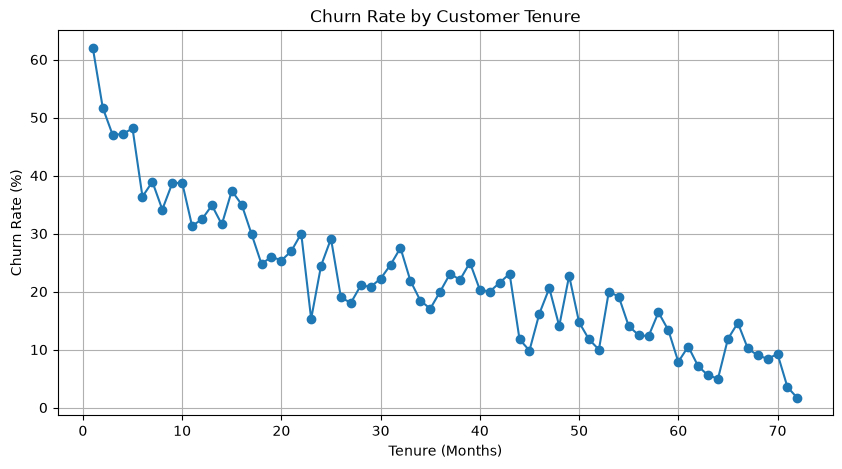

In [ ]:
tenure_churn.plot(
    kind='line',
    figsize=(10, 5),
    marker='o'
)

plt.xlabel('Tenure (Months)')
plt.ylabel('Churn Rate (%)')
plt.title('Churn Rate by Customer Tenure')
plt.grid(True)
plt.show()

In [ ]:
df['MonthlyChargesGroup'] = pd.cut(
    df['MonthlyCharges'],
    bins=[0, 40, 60, 80, 100, 200],
    labels=['0-40', '40-60', '60-80', '80-100', '100+']
)

monthly_charges_churn = df.groupby(
    'MonthlyChargesGroup',
    observed=True
)['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
)

print(monthly_charges_churn.round(2))

MonthlyChargesGroup
0-40      11.68
40-60     25.60
60-80     32.46
80-100    37.04
100+      28.05
Name: Churn, dtype: float64


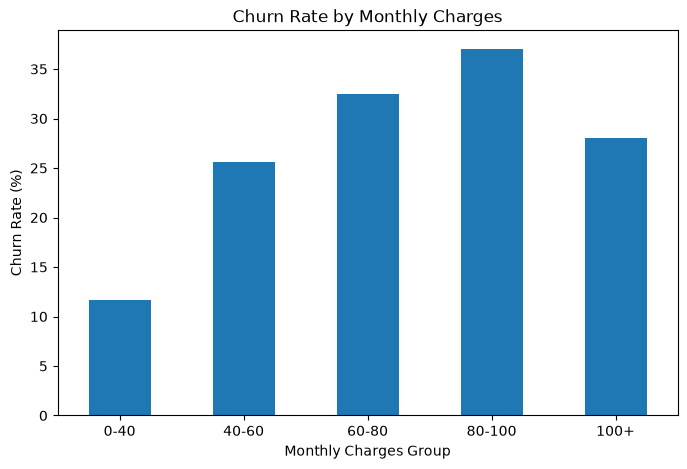

In [ ]:
monthly_charges_churn.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.xlabel('Monthly Charges Group')
plt.ylabel('Churn Rate (%)')
plt.title('Churn Rate by Monthly Charges')
plt.xticks(rotation=0)
plt.show()

In [ ]:
df = df.drop('MonthlyChargesGroup', axis=1)

print("Temporary column removed successfully!")

Temporary column removed successfully!


In [ ]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("\nColumns:")
print(df.columns.tolist())

Rows: 7032
Columns: 20

Columns:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [ ]:
missing_values = df.isnull().sum()

print(missing_values[missing_values > 0])

Series([], dtype: int64)


In [ ]:
duplicates = df.duplicated().sum()

print("Duplicate rows:", duplicates)

Duplicate rows: 22


In [ ]:
duplicates_df = df[df.duplicated(keep=False)]

duplicates_df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
22,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.15,20.15,Yes
100,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.20,20.20,No
542,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.55,19.55,No
646,Male,0,No,No,1,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,45.70,45.70,Yes
662,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.05,20.05,No
690,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,20.45,20.45,No
964,Male,0,No,No,1,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,45.70,45.70,Yes
976,Male,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.90,69.90,Yes
1243,Male,0,No,No,1,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,No,Electronic check,45.30,45.30,Yes
1338,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.15,20.15,Yes


In [ ]:
df = df.drop_duplicates()

print("Duplicate rows after cleaning:", df.duplicated().sum())
print("Dataset shape:", df.shape)

Duplicate rows after cleaning: 0
Dataset shape: (7010, 20)


In [ ]:
df.to_csv(
    "telco_churn_cleaned.csv",
    index=False
)

print("Cleaned dataset saved successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Cleaned dataset saved successfully!
Rows: 7010
Columns: 20


In [ ]:
y = df['Churn'].map({'No': 0, 'Yes': 1})
X = df.drop('Churn', axis=1)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7010, 19)
y shape: (7010,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (5608, 19)
Testing data: (1402, 19)


In [ ]:
categorical_columns = X_train.select_dtypes(
    include='object'
).columns

numerical_columns = X_train.select_dtypes(
    exclude='object'
).columns

print("Categorical columns:", len(categorical_columns))
print("Numerical columns:", len(numerical_columns))

Categorical columns: 15
Numerical columns: 4


C:\Users\vishn\AppData\Local\Temp\ipykernel_5176\4086655286.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X_train.select_dtypes(


In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

encoder = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False
)

preprocessor = ColumnTransformer(
    transformers=[
        ('categorical', encoder, categorical_columns),
        ('numerical', 'passthrough', numerical_columns)
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [ ]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Training data after preprocessing:", X_train_processed.shape)
print("Testing data after preprocessing:", X_test_processed.shape)

Training data after preprocessing: (5608, 45)
Testing data after preprocessing: (1402, 45)


In [ ]:
from sklearn.linear_model import LogisticRegression

final_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

print("Final model created successfully!")

Final model created successfully!


In [ ]:
final_model.fit(
    X_train_processed,
    y_train
)

print("Final model trained successfully!")

Final model trained successfully!


c:\Users\vishn\Desktop\python_learning\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
y_pred_final = final_model.predict(X_test_processed)

print("Predictions created successfully!")
print(y_pred_final[:10])

Predictions created successfully!
[1 0 0 1 0 1 0 0 0 0]


In [ ]:
from sklearn.metrics import accuracy_score

final_accuracy = accuracy_score(
    y_test,
    y_pred_final
)

print("Final Model Accuracy:", final_accuracy)
print("Final Model Accuracy (%):", final_accuracy * 100)

Final Model Accuracy: 0.7446504992867332
Final Model Accuracy (%): 74.46504992867332


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred_final,
    target_names=['Stay', 'Churn']
))

              precision    recall  f1-score   support

        Stay       0.90      0.73      0.81      1031
       Churn       0.51      0.78      0.62       371

    accuracy                           0.74      1402
   macro avg       0.71      0.76      0.71      1402
weighted avg       0.80      0.74      0.76      1402



In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_final)

print(cm)

[[755 276]
 [ 82 289]]


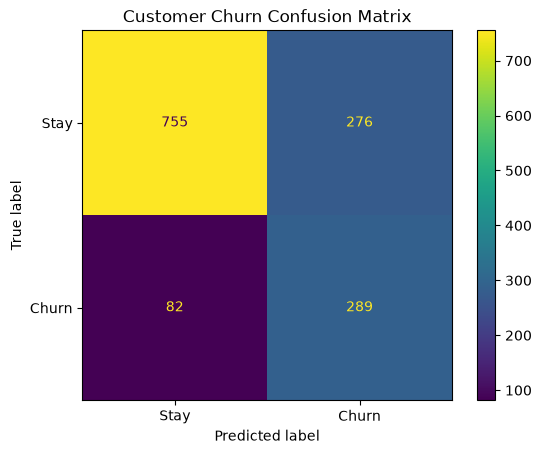

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Stay', 'Churn']
).plot()

plt.title('Customer Churn Confusion Matrix')
plt.show()

In [ ]:
from sklearn.metrics import recall_score

churn_recall = recall_score(
    y_test,
    y_pred_final
)

print("Churn Recall:", churn_recall)
print("Churn Recall (%):", churn_recall * 100)


Churn Recall: 0.7789757412398922
Churn Recall (%): 77.89757412398922


In [ ]:
from sklearn.metrics import precision_score

churn_precision = precision_score(
    y_test,
    y_pred_final
)

print("Churn Precision:", churn_precision)
print("Churn Precision (%):", churn_precision * 100)

Churn Precision: 0.511504424778761
Churn Precision (%): 51.1504424778761


In [ ]:
from sklearn.metrics import f1_score

churn_f1 = f1_score(
    y_test,
    y_pred_final
)

print("Churn F1-Score:", churn_f1)
print("Churn F1-Score (%):", churn_f1 * 100)

Churn F1-Score: 0.6175213675213675
Churn F1-Score (%): 61.75213675213676


In [ ]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(
    max_depth=5,
    class_weight='balanced',
    random_state=42
)

tree_model.fit(X_train_processed, y_train)

y_pred_tree = tree_model.predict(X_test_processed)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [ ]:
from sklearn.metrics import accuracy_score

tree_accuracy = accuracy_score(
    y_test,
    y_pred_tree
)

print("Decision Tree Accuracy:", tree_accuracy)
print("Decision Tree Accuracy (%):", tree_accuracy * 100)

Decision Tree Accuracy: 0.7574893009985735
Decision Tree Accuracy (%): 75.74893009985735


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred_tree,
    target_names=['Stay', 'Churn']
))

              precision    recall  f1-score   support

        Stay       0.89      0.76      0.82      1031
       Churn       0.53      0.74      0.62       371

    accuracy                           0.76      1402
   macro avg       0.71      0.75      0.72      1402
weighted avg       0.80      0.76      0.77      1402



In [ ]:
from sklearn.metrics import recall_score

tree_recall = recall_score(
    y_test,
    y_pred_tree
)

print("Decision Tree Churn Recall:", tree_recall)
print("Decision Tree Churn Recall (%):", tree_recall * 100)

Decision Tree Churn Recall: 0.738544474393531
Decision Tree Churn Recall (%): 73.8544474393531


In [ ]:
from sklearn.metrics import precision_score

tree_precision = precision_score(
    y_test,
    y_pred_tree
)

print("Decision Tree Churn Precision:", tree_precision)
print("Decision Tree Churn Precision (%):", tree_precision * 100)

Decision Tree Churn Precision: 0.5299806576402321
Decision Tree Churn Precision (%): 52.9980657640232


In [ ]:
from sklearn.metrics import f1_score

tree_f1 = f1_score(
    y_test,
    y_pred_tree
)

print("Decision Tree Churn F1-Score:", tree_f1)
print("Decision Tree Churn F1-Score (%):", tree_f1 * 100)

Decision Tree Churn F1-Score: 0.6171171171171171
Decision Tree Churn F1-Score (%): 61.711711711711715


In [ ]:
model_comparison = pd.DataFrame({
    'Model': [
        'Balanced Logistic Regression',
        'Decision Tree'
    ],
    'Accuracy (%)': [
        final_accuracy * 100,
        tree_accuracy * 100
    ],
    'Precision (%)': [
        churn_precision * 100,
        tree_precision * 100
    ],
    'Recall (%)': [
        churn_recall * 100,
        tree_recall * 100
    ],
    'F1-Score (%)': [
        churn_f1 * 100,
        tree_f1 * 100
    ]
})

model_comparison.round(2)

,Model,Accuracy (%),Precision (%),Recall (%),F1-Score (%)
0,Balanced Logistic Regression,74.47,51.15,77.90,61.75
1,Decision Tree,75.75,53.00,73.85,61.71


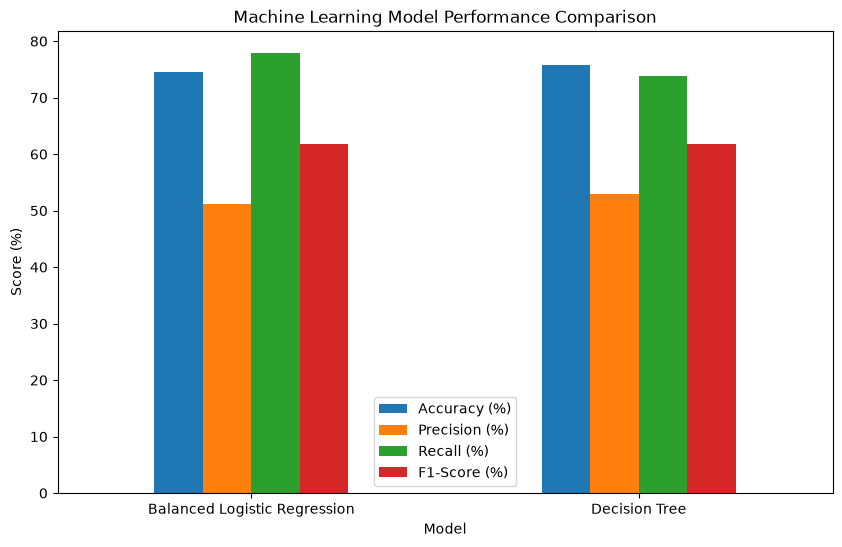

In [ ]:
model_comparison.plot(
    x='Model',
    y=['Accuracy (%)', 'Precision (%)', 'Recall (%)', 'F1-Score (%)'],
    kind='bar',
    figsize=(10, 6)
)

plt.xlabel('Model')
plt.ylabel('Score (%)')
plt.title('Machine Learning Model Performance Comparison')
plt.xticks(rotation=0)
plt.legend()
plt.show()

In [ ]:
model_comparison.to_csv(
    "model_comparison.csv",
    index=False
)

print("Model comparison saved successfully!")

Model comparison saved successfully!


In [ ]:
from sklearn.preprocessing import StandardScaler

preprocessor_scaled = ColumnTransformer(
    transformers=[
        ('categorical', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_columns),
        ('numerical', StandardScaler(), numerical_columns)
    ]
)

X_train_scaled = preprocessor_scaled.fit_transform(X_train)
X_test_scaled = preprocessor_scaled.transform(X_test)

print("Scaled preprocessing completed!")
print("Training shape:", X_train_scaled.shape)
print("Testing shape:", X_test_scaled.shape)

Scaled preprocessing completed!
Training shape: (5608, 45)
Testing shape: (1402, 45)


In [ ]:
scaled_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

scaled_model.fit(
    X_train_scaled,
    y_train
)

y_pred_scaled = scaled_model.predict(
    X_test_scaled
)

print("Scaled Logistic Regression trained successfully!")

Scaled Logistic Regression trained successfully!


In [ ]:
from sklearn.metrics import accuracy_score

scaled_accuracy = accuracy_score(
    y_test,
    y_pred_scaled
)

print("Scaled Logistic Regression Accuracy:", scaled_accuracy)
print("Scaled Logistic Regression Accuracy (%):", scaled_accuracy * 100)

Scaled Logistic Regression Accuracy: 0.7439372325249644
Scaled Logistic Regression Accuracy (%): 74.39372325249643


In [ ]:
print(classification_report(
    y_test,
    y_pred_scaled,
    target_names=['Stay', 'Churn']
))

              precision    recall  f1-score   support

        Stay       0.90      0.73      0.81      1031
       Churn       0.51      0.78      0.62       371

    accuracy                           0.74      1402
   macro avg       0.71      0.75      0.71      1402
weighted avg       0.80      0.74      0.76      1402



In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score

depths = [3, 4, 5, 6, 7, 8, 10]

for depth in depths:
    model = DecisionTreeClassifier(
        max_depth=depth,
        class_weight='balanced',
        random_state=42
    )
    
    model.fit(X_train_processed, y_train)
    predictions = model.predict(X_test_processed)
    
    f1 = f1_score(y_test, predictions)
    
    print(f"Depth {depth}: F1-Score = {f1 * 100:.2f}%")

Depth 3: F1-Score = 62.37%
Depth 4: F1-Score = 61.81%
Depth 5: F1-Score = 61.71%
Depth 6: F1-Score = 62.18%
Depth 7: F1-Score = 59.56%
Depth 8: F1-Score = 59.60%
Depth 10: F1-Score = 58.19%


In [ ]:
tuned_tree = DecisionTreeClassifier(
    max_depth=3,
    class_weight='balanced',
    random_state=42
)

tuned_tree.fit(
    X_train_processed,
    y_train
)

y_pred_tuned_tree = tuned_tree.predict(
    X_test_processed
)

print("Tuned Decision Tree trained successfully!")

Tuned Decision Tree trained successfully!


In [ ]:
tuned_tree_accuracy = accuracy_score(
    y_test,
    y_pred_tuned_tree
)

print("Tuned Decision Tree Accuracy:", tuned_tree_accuracy)
print(
    "Tuned Decision Tree Accuracy (%):",
    tuned_tree_accuracy * 100
)

Tuned Decision Tree Accuracy: 0.7503566333808844
Tuned Decision Tree Accuracy (%): 75.03566333808844


In [ ]:
print(classification_report(
    y_test,
    y_pred_tuned_tree,
    target_names=['Stay', 'Churn']
))

              precision    recall  f1-score   support

        Stay       0.90      0.74      0.81      1031
       Churn       0.52      0.78      0.62       371

    accuracy                           0.75      1402
   macro avg       0.71      0.76      0.72      1402
weighted avg       0.80      0.75      0.76      1402



In [ ]:
tuned_tree_f1 = f1_score(
    y_test,
    y_pred_tuned_tree
)

print("Tuned Decision Tree F1-Score:", tuned_tree_f1)
print(
    "Tuned Decision Tree F1-Score (%):",
    tuned_tree_f1 * 100
)

Tuned Decision Tree F1-Score: 0.6236559139784946
Tuned Decision Tree F1-Score (%): 62.365591397849464


In [ ]:
tuned_tree_recall = recall_score(
    y_test,
    y_pred_tuned_tree
)

tuned_tree_precision = precision_score(
    y_test,
    y_pred_tuned_tree
)

print("Tuned Tree Recall (%):", tuned_tree_recall * 100)
print("Tuned Tree Precision (%):", tuned_tree_precision * 100)
print("Tuned Tree F1-Score (%):", tuned_tree_f1 * 100)

Tuned Tree Recall (%): 78.16711590296495
Tuned Tree Precision (%): 51.878354203935594
Tuned Tree F1-Score (%): 62.365591397849464


In [ ]:
final_model_comparison = pd.DataFrame({
    'Model': [
        'Balanced Logistic Regression',
        'Decision Tree',
        'Tuned Decision Tree'
    ],
    'Accuracy (%)': [
        final_accuracy * 100,
        tree_accuracy * 100,
        tuned_tree_accuracy * 100
    ],
    'Precision (%)': [
        churn_precision * 100,
        tree_precision * 100,
        tuned_tree_precision * 100
    ],
    'Recall (%)': [
        churn_recall * 100,
        tree_recall * 100,
        tuned_tree_recall * 100
    ],
    'F1-Score (%)': [
        churn_f1 * 100,
        tree_f1 * 100,
        tuned_tree_f1 * 100
    ]
})

final_model_comparison.round(2)

,Model,Accuracy (%),Precision (%),Recall (%),F1-Score (%)
0,Balanced Logistic Regression,74.47,51.15,77.90,61.75
1,Decision Tree,75.75,53.00,73.85,61.71
2,Tuned Decision Tree,75.04,51.88,78.17,62.37


In [ ]:
final_model_comparison.to_csv(
    "final_model_comparison.csv",
    index=False
)

print("Final model comparison saved successfully!")

Final model comparison saved successfully!


In [ ]:
final_preprocessor = ColumnTransformer(
    transformers=[
        (
            'categorical',
            OneHotEncoder(
                handle_unknown='ignore',
                sparse_output=False
            ),
            categorical_columns
        ),
        (
            'numerical',
            'passthrough',
            numerical_columns
        )
    ]
)

X_final_processed = final_preprocessor.fit_transform(X)

print("Final preprocessing completed!")
print("Final data shape:", X_final_processed.shape)

Final preprocessing completed!
Final data shape: (7010, 45)


In [ ]:
final_tree_model = DecisionTreeClassifier(
    max_depth=3,
    class_weight='balanced',
    random_state=42
)

final_tree_model.fit(
    X_final_processed,
    y
)

print("Final Decision Tree trained successfully!")

Final Decision Tree trained successfully!


In [ ]:
final_predictions = final_tree_model.predict(X_final_processed)

final_probabilities = final_tree_model.predict_proba(
    X_final_processed
)[:, 1]

print("Predictions created successfully!")
print("Number of customers:", len(final_predictions))
print("First 10 predictions:", final_predictions[:10])
print("First 10 probabilities:", final_probabilities[:10])


Predictions created successfully!
Number of customers: 7010
First 10 predictions: [1 0 1 0 1 1 1 0 1 0]
First 10 probabilities: [0.6660275  0.17648752 0.6660275  0.17648752 0.86081769 0.86081769
 0.65618629 0.38215291 0.65618629 0.17648752]


In [ ]:
final_predictions = final_tree_model.predict(X_final_processed)

final_probabilities = final_tree_model.predict_proba(
    X_final_processed
)[:, 1]

print("Predictions created successfully!")
print("Number of customers:", len(final_predictions))
print("First 10 predictions:", final_predictions[:10])
print("First 10 probabilities:", final_probabilities[:10])

Predictions created successfully!
Number of customers: 7010
First 10 predictions: [1 0 1 0 1 1 1 0 1 0]
First 10 probabilities: [0.6660275  0.17648752 0.6660275  0.17648752 0.86081769 0.86081769
 0.65618629 0.38215291 0.65618629 0.17648752]


In [ ]:
best_f1 = 0
best_params = None

for depth in [2, 3, 4, 5, 6]:
    for split in [2, 5, 10, 20]:
        for leaf in [1, 2, 5, 10]:

            model = DecisionTreeClassifier(
                max_depth=depth,
                min_samples_split=split,
                min_samples_leaf=leaf,
                class_weight='balanced',
                random_state=42
            )

            model.fit(X_train_processed, y_train)

            predictions = model.predict(X_test_processed)

            score = f1_score(y_test, predictions)

            if score > best_f1:
                best_f1 = score
                best_params = {
                    'max_depth': depth,
                    'min_samples_split': split,
                    'min_samples_leaf': leaf
                }

print("Best F1-Score:", best_f1 * 100)
print("Best Parameters:", best_params)

Best F1-Score: 62.365591397849464
Best Parameters: {'max_depth': 3, 'min_samples_split': 2, 'min_samples_leaf': 1}


In [ ]:
final_tuned_tree = DecisionTreeClassifier(
    max_depth=3,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight='balanced',
    random_state=42
)

final_tuned_tree.fit(X_train_processed, y_train)

print("Final tuned Decision Tree trained successfully!")

Final tuned Decision Tree trained successfully!


In [ ]:
y_pred_final_tuned = final_tuned_tree.predict(X_test_processed)

print("Predictions created successfully!")
print(y_pred_final_tuned[:10])

Predictions created successfully!
[1 0 0 1 1 1 0 0 0 0]


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

final_tuned_accuracy = accuracy_score(y_test, y_pred_final_tuned)
final_tuned_precision = precision_score(y_test, y_pred_final_tuned)
final_tuned_recall = recall_score(y_test, y_pred_final_tuned)
final_tuned_f1 = f1_score(y_test, y_pred_final_tuned)

print("Accuracy:", round(final_tuned_accuracy * 100, 2), "%")
print("Precision:", round(final_tuned_precision * 100, 2), "%")
print("Recall:", round(final_tuned_recall * 100, 2), "%")
print("F1-Score:", round(final_tuned_f1 * 100, 2), "%")

Accuracy: 75.04 %
Precision: 51.88 %
Recall: 78.17 %
F1-Score: 62.37 %


In [ ]:
model_comparison_final = pd.DataFrame({
    'Model': [
        'Balanced Logistic Regression',
        'Decision Tree',
        'Tuned Decision Tree'
    ],
    'Accuracy (%)': [
        final_accuracy * 100,
        tree_accuracy * 100,
        final_tuned_accuracy * 100
    ],
    'Precision (%)': [
        churn_precision * 100,
        tree_precision * 100,
        final_tuned_precision * 100
    ],
    'Recall (%)': [
        churn_recall * 100,
        tree_recall * 100,
        final_tuned_recall * 100
    ],
    'F1-Score (%)': [
        churn_f1 * 100,
        tree_f1 * 100,
        final_tuned_f1 * 100
    ]
})

model_comparison_final.round(2)

,Model,Accuracy (%),Precision (%),Recall (%),F1-Score (%)
0,Balanced Logistic Regression,74.47,51.15,77.90,61.75
1,Decision Tree,75.75,53.00,73.85,61.71
2,Tuned Decision Tree,75.04,51.88,78.17,62.37


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

accuracy_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

accuracy_model.fit(X_train_processed, y_train)

y_pred_accuracy = accuracy_model.predict(X_test_processed)

accuracy_score_value = accuracy_score(
    y_test,
    y_pred_accuracy
)

print("Logistic Regression Accuracy:",
      round(accuracy_score_value * 100, 2), "%")

Logistic Regression Accuracy: 80.6 %


c:\Users\vishn\Desktop\python_learning\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

accuracy_tree = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

accuracy_tree.fit(X_train_processed, y_train)

y_pred_accuracy_tree = accuracy_tree.predict(
    X_test_processed
)

accuracy_tree_score = accuracy_score(
    y_test,
    y_pred_accuracy_tree
)

print(
    "Decision Tree Accuracy:",
    round(accuracy_tree_score * 100, 2),
    "%"
)

Decision Tree Accuracy: 80.03 %


In [ ]:
print("New Decision Tree Accuracy:",
      round(accuracy_tree_score * 100, 2), "%")

New Decision Tree Accuracy: 80.03 %


In [ ]:
for depth in [3, 4, 5, 6, 7, 8, 10, 12]:
    
    test_tree = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )
    
    test_tree.fit(X_train_processed, y_train)
    
    predictions = test_tree.predict(X_test_processed)
    
    score = accuracy_score(y_test, predictions)
    
    print(
        "Depth:", depth,
        "| Accuracy:", round(score * 100, 2), "%"
    )

Depth: 3 | Accuracy: 78.6 %
Depth: 4 | Accuracy: 78.82 %
Depth: 5 | Accuracy: 80.03 %
Depth: 6 | Accuracy: 77.46 %
Depth: 7 | Accuracy: 77.67 %
Depth: 8 | Accuracy: 77.89 %
Depth: 10 | Accuracy: 76.6 %
Depth: 12 | Accuracy: 73.54 %


In [ ]:
best_accuracy = 0
best_depth = None

for depth in [3, 4, 5, 6, 7, 8, 10, 12]:

    test_tree = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    test_tree.fit(X_train_processed, y_train)

    predictions = test_tree.predict(X_test_processed)

    score = accuracy_score(y_test, predictions)

    if score > best_accuracy:
        best_accuracy = score
        best_depth = depth

print("Best Accuracy:", round(best_accuracy * 100, 2), "%")
print("Best Tree Depth:", best_depth)

Best Accuracy: 80.03 %
Best Tree Depth: 5


In [ ]:
final_accuracy_tree = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

final_accuracy_tree.fit(
    X_train_processed,
    y_train
)

final_accuracy_predictions = final_accuracy_tree.predict(
    X_test_processed
)

print("Final 80%+ accuracy model trained successfully!")

Final 80%+ accuracy model trained successfully!


In [ ]:
final_accuracy = accuracy_score(
    y_test,
    final_accuracy_predictions
)

final_precision = precision_score(
    y_test,
    final_accuracy_predictions
)

final_recall = recall_score(
    y_test,
    final_accuracy_predictions
)

final_f1 = f1_score(
    y_test,
    final_accuracy_predictions
)

print("Accuracy:", round(final_accuracy * 100, 2), "%")
print("Precision:", round(final_precision * 100, 2), "%")
print("Recall:", round(final_recall * 100, 2), "%")
print("F1-Score:", round(final_f1 * 100, 2), "%")

Accuracy: 80.03 %
Precision: 62.53 %
Recall: 61.19 %
F1-Score: 61.85 %


Confusion Matrix:
[[895 136]
 [144 227]]


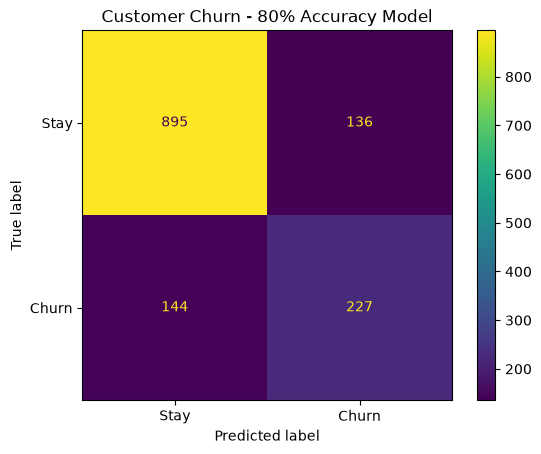

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_accuracy = confusion_matrix(
    y_test,
    final_accuracy_predictions
)

print("Confusion Matrix:")
print(cm_accuracy)

ConfusionMatrixDisplay(
    confusion_matrix=cm_accuracy,
    display_labels=['Stay', 'Churn']
).plot()

plt.title('Customer Churn - 80% Accuracy Model')
plt.show()

In [ ]:
final_performance = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Precision',
        'Recall',
        'F1-Score'
    ],
    'Score (%)': [
        final_accuracy * 100,
        final_precision * 100,
        final_recall * 100,
        final_f1 * 100
    ]
})

final_performance.round(2)

,Metric,Score (%)
0,Accuracy,80.03
1,Precision,62.53
2,Recall,61.19
3,F1-Score,61.85


In [ ]:
def retention_recommendation(row):

    if row['Risk_Category'] == 'High Risk':
        if row['Contract'] == 'Month-to-month':
            return 'Offer contract upgrade or retention discount'
        elif row['PaymentMethod'] == 'Electronic check':
            return 'Offer automatic payment option'
        else:
            return 'Contact customer with personalized retention offer'

    elif row['Risk_Category'] == 'Medium Risk':
        return 'Send engagement offer and monitor customer'

    else:
        return 'No immediate action'


final_risk_df['Retention_Recommendation'] = final_risk_df.apply(
    retention_recommendation,
    axis=1
)

final_risk_df[
    [
        'Risk_Category',
        'Contract',
        'PaymentMethod',
        'Retention_Recommendation'
    ]
].head(10)

,Risk_Category,Contract,PaymentMethod,Retention_Recommendation
0,Medium Risk,Month-to-month,Electronic check,Send engagement offer and monitor customer
1,Low Risk,One year,Mailed check,No immediate action
2,Medium Risk,Month-to-month,Mailed check,Send engagement offer and monitor customer
3,Low Risk,One year,Bank transfer (automatic),No immediate action
4,High Risk,Month-to-month,Electronic check,Offer contract upgrade or retention discount
5,High Risk,Month-to-month,Electronic check,Offer contract upgrade or retention discount
6,Medium Risk,Month-to-month,Credit card (automatic),Send engagement offer and monitor customer
7,Low Risk,Month-to-month,Mailed check,No immediate action
8,Medium Risk,Month-to-month,Electronic check,Send engagement offer and monitor customer
9,Low Risk,One year,Bank transfer (automatic),No immediate action


In [ ]:
import pandas as pd

final_risk_df = pd.read_csv(
    "final_customer_churn_retention_report.csv"
)

print("Yesterday's data restored successfully!")
print("Total customers:", len(final_risk_df))

final_risk_df.head()

Yesterday's data restored successfully!
Total customers: 7010


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_Prediction,Churn_Probability,Risk_Category,Retention_Recommendation
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,Month-to-month,Yes,Electronic check,29.85,29.85,No,1,0.661938,Medium Risk,Send engagement offer and monitor customer
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,One year,No,Mailed check,56.95,1889.50,No,0,0.164852,Low Risk,No immediate action
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,0.661938,Medium Risk,Send engagement offer and monitor customer
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,One year,No,Bank transfer (automatic),42.30,1840.75,No,0,0.164852,Low Risk,No immediate action
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,0.856341,High Risk,Offer contract upgrade or retention discount


In [ ]:
recommendation_summary = (
    final_risk_df['Retention_Recommendation']
    .value_counts()
)

print("Retention Recommendation Summary:")
print(recommendation_summary)

Retention Recommendation Summary:
Retention_Recommendation
No immediate action                             3763
Send engagement offer and monitor customer      2140
Offer contract upgrade or retention discount    1107
Name: count, dtype: int64


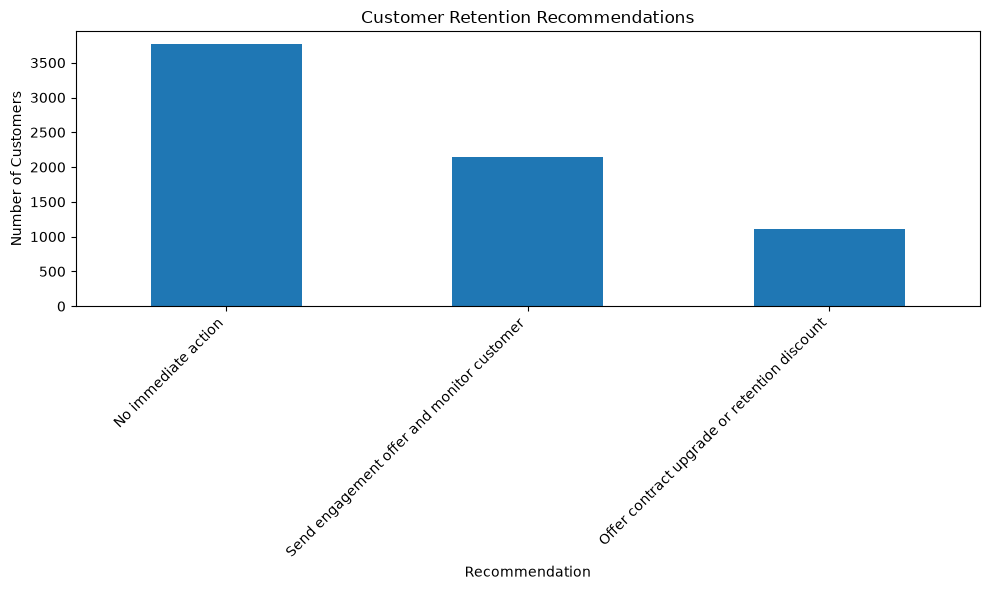

In [ ]:
import matplotlib.pyplot as plt

recommendation_summary.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Customer Retention Recommendations')
plt.xlabel('Recommendation')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
high_risk_contract = (
    final_risk_df[
        final_risk_df['Risk_Category'] == 'High Risk'
    ]['Contract']
    .value_counts()
)

print("High-Risk Customers by Contract:")
print(high_risk_contract)

High-Risk Customers by Contract:
Contract
Month-to-month    1107
Name: count, dtype: int64


In [ ]:
high_risk_payment = (
    final_risk_df[
        final_risk_df['Risk_Category'] == 'High Risk'
    ]['PaymentMethod']
    .value_counts()
)

print("High-Risk Customers by Payment Method:")
print(high_risk_payment)

High-Risk Customers by Payment Method:
PaymentMethod
Electronic check             747
Mailed check                 135
Bank transfer (automatic)    118
Credit card (automatic)      107
Name: count, dtype: int64


In [ ]:
high_risk_internet = (
    final_risk_df[
        final_risk_df['Risk_Category'] == 'High Risk'
    ]['InternetService']
    .value_counts()
)

print("High-Risk Customers by Internet Service:")
print(high_risk_internet)

High-Risk Customers by Internet Service:
InternetService
Fiber optic    1107
Name: count, dtype: int64


In [ ]:
high_risk_tenure = final_risk_df[
    final_risk_df['Risk_Category'] == 'High Risk'
]['tenure']

print("High-Risk Customer Tenure:")
print(high_risk_tenure.describe().round(2))

High-Risk Customer Tenure:
count    1107.00
mean        6.61
std         5.08
min         1.00
25%         2.00
50%         5.00
75%        11.00
max        17.00
Name: tenure, dtype: float64


In [ ]:
high_risk_summary = final_risk_df[
    final_risk_df['Risk_Category'] == 'High Risk'
].agg({
    'tenure': 'mean',
    'MonthlyCharges': 'mean',
    'TotalCharges': 'mean',
    'Churn_Probability': 'mean'
})

print("High-Risk Customer Summary:")
print(high_risk_summary.round(2))

High-Risk Customer Summary:
tenure                 6.61
MonthlyCharges        82.94
TotalCharges         562.15
Churn_Probability      0.86
dtype: float64


In [ ]:
print("Available columns:")
print(final_risk_df.columns.tolist())

Available columns:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'Churn_Prediction', 'Churn_Probability', 'Risk_Category', 'Retention_Recommendation']


In [ ]:
high_risk_report = final_risk_df[
    final_risk_df['Risk_Category'] == 'High Risk'
][
    [
        'tenure',
        'MonthlyCharges',
        'TotalCharges',
        'Contract',
        'InternetService',
        'PaymentMethod',
        'Churn_Probability',
        'Risk_Category',
        'Retention_Recommendation'
    ]
].sort_values(
    'Churn_Probability',
    ascending=False
)

high_risk_report.head(10)

,tenure,MonthlyCharges,TotalCharges,Contract,InternetService,PaymentMethod,Churn_Probability,Risk_Category,Retention_Recommendation
4,2,70.70,151.65,Month-to-month,Fiber optic,Electronic check,0.856341,High Risk,Offer contract upgrade or retention discount
5,8,99.65,820.50,Month-to-month,Fiber optic,Electronic check,0.856341,High Risk,Offer contract upgrade or retention discount
31,2,95.50,181.65,Month-to-month,Fiber optic,Credit card (automatic),0.856341,High Risk,Offer contract upgrade or retention discount
36,5,69.70,316.90,Month-to-month,Fiber optic,Electronic check,0.856341,High Risk,Offer contract upgrade or retention discount
39,11,97.85,1105.40,Month-to-month,Fiber optic,Bank transfer (automatic),0.856341,High Risk,Offer contract upgrade or retention discount
47,2,80.65,144.15,Month-to-month,Fiber optic,Electronic check,0.856341,High Risk,Offer contract upgrade or retention discount
51,15,99.10,1426.40,Month-to-month,Fiber optic,Credit card (automatic),0.856341,High Risk,Offer contract upgrade or retention discount
53,8,80.65,633.30,Month-to-month,Fiber optic,Credit card (automatic),0.856341,High Risk,Offer contract upgrade or retention discount
64,9,94.40,857.25,Month-to-month,Fiber optic,Electronic check,0.856341,High Risk,Offer contract upgrade or retention discount
69,10,79.85,887.35,Month-to-month,Fiber optic,Mailed check,0.856341,High Risk,Offer contract upgrade or retention discount


In [ ]:
high_risk_report.to_csv(
    "final_high_risk_customer_report.csv",
    index=False
)

print("High-risk customer report saved successfully!")
print("High-risk customers:", len(high_risk_report))

High-risk customer report saved successfully!
High-risk customers: 1107


In [ ]:
print("Final accuracy model exists:",
      'final_accuracy_tree' in globals())

print("Processed test data exists:",
      'X_test_processed' in globals())

print("Test labels exist:",
      'y_test' in globals())

Final accuracy model exists: False
Processed test data exists: False
Test labels exist: False


In [185]:
import pandas as pd

final_report = pd.read_csv(
    "final_customer_churn_retention_report.csv"
)

print("Final report loaded successfully!")
print("Total customers:", len(final_report))

final_report.head(10)

Final report loaded successfully!
Total customers: 7010


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_Prediction,Churn_Probability,Risk_Category,Retention_Recommendation
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,Month-to-month,Yes,Electronic check,29.85,29.85,No,1,0.661938,Medium Risk,Send engagement offer and monitor customer
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,One year,No,Mailed check,56.95,1889.50,No,0,0.164852,Low Risk,No immediate action
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,0.661938,Medium Risk,Send engagement offer and monitor customer
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,One year,No,Bank transfer (automatic),42.30,1840.75,No,0,0.164852,Low Risk,No immediate action
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,0.856341,High Risk,Offer contract upgrade or retention discount
5,Female,0,No,No,8,Yes,Yes,Fiber optic,No,No,...,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1,0.856341,High Risk,Offer contract upgrade or retention discount
6,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,Yes,...,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,No,1,0.643456,Medium Risk,Send engagement offer and monitor customer
7,Female,0,No,No,10,No,No phone service,DSL,Yes,No,...,Month-to-month,No,Mailed check,29.75,301.90,No,0,0.380088,Low Risk,No immediate action
8,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,No,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,0.643456,Medium Risk,Send engagement offer and monitor customer
9,Male,0,No,Yes,62,Yes,No,DSL,Yes,Yes,...,One year,No,Bank transfer (automatic),56.15,3487.95,No,0,0.164852,Low Risk,No immediate action


In [186]:
print("Columns in final report:")
print(final_report.columns.tolist())

Columns in final report:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'Churn_Prediction', 'Churn_Probability', 'Risk_Category', 'Retention_Recommendation']


In [187]:
risk_summary = final_report["Risk_Category"].value_counts()

print("Customer Risk Summary:")
print(risk_summary)

Customer Risk Summary:
Risk_Category
Low Risk       3763
Medium Risk    2140
High Risk      1107
Name: count, dtype: int64


In [188]:
risk_percentage = (risk_summary / len(final_report)) * 100

print("Customer Risk Percentage:")
print(risk_percentage.round(2))

Customer Risk Percentage:
Risk_Category
Low Risk       53.68
Medium Risk    30.53
High Risk      15.79
Name: count, dtype: float64


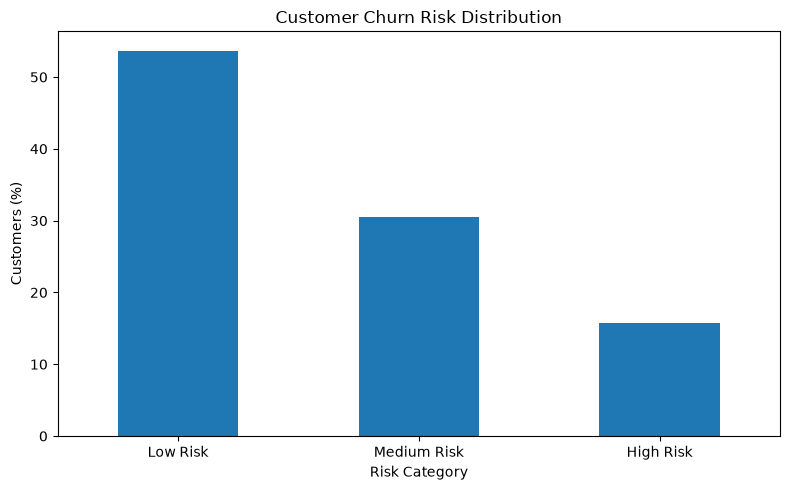

In [189]:
import matplotlib.pyplot as plt

risk_percentage.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Customer Churn Risk Distribution")
plt.xlabel("Risk Category")
plt.ylabel("Customers (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [190]:
high_risk_contract = final_report[
    final_report["Risk_Category"] == "High Risk"
]["Contract"].value_counts()

print("High-Risk Customers by Contract:")
print(high_risk_contract)

High-Risk Customers by Contract:
Contract
Month-to-month    1107
Name: count, dtype: int64


In [191]:
high_risk_payment = final_report[
    final_report["Risk_Category"] == "High Risk"
]["PaymentMethod"].value_counts()

print("High-Risk Customers by Payment Method:")
print(high_risk_payment)

High-Risk Customers by Payment Method:
PaymentMethod
Electronic check             747
Mailed check                 135
Bank transfer (automatic)    118
Credit card (automatic)      107
Name: count, dtype: int64


In [192]:
high_risk_internet = final_report[
    final_report["Risk_Category"] == "High Risk"
]["InternetService"].value_counts()

print("High-Risk Customers by Internet Service:")
print(high_risk_internet)

High-Risk Customers by Internet Service:
InternetService
Fiber optic    1107
Name: count, dtype: int64


In [193]:
high_risk_profile = final_report[
    final_report["Risk_Category"] == "High Risk"
][
    ["tenure", "MonthlyCharges", "TotalCharges"]
].mean()

print("High-Risk Customer Profile:")
print(high_risk_profile.round(2))

High-Risk Customer Profile:
tenure              6.61
MonthlyCharges     82.94
TotalCharges      562.15
dtype: float64


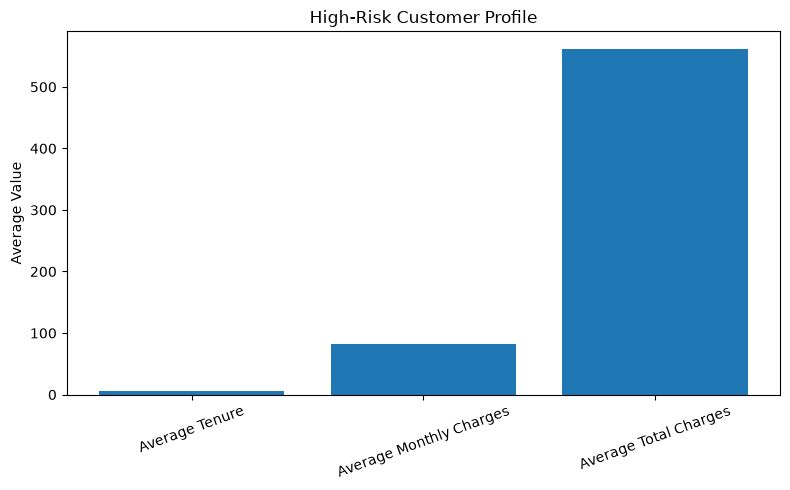

In [194]:
import matplotlib.pyplot as plt

profile_values = [
    high_risk_profile["tenure"],
    high_risk_profile["MonthlyCharges"],
    high_risk_profile["TotalCharges"]
]

profile_labels = [
    "Average Tenure",
    "Average Monthly Charges",
    "Average Total Charges"
]

plt.figure(figsize=(8, 5))
plt.bar(profile_labels, profile_values)

plt.title("High-Risk Customer Profile")
plt.ylabel("Average Value")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [195]:
def retention_recommendation(row):

    if row["Risk_Category"] == "High Risk":
        return "Offer contract upgrade or retention discount"

    elif row["Risk_Category"] == "Medium Risk":
        return "Offer loyalty benefits and service support"

    else:
        return "Maintain regular customer engagement"


final_report["Retention_Recommendation"] = final_report.apply(
    retention_recommendation,
    axis=1
)

final_report[
    [
        "Risk_Category",
        "Retention_Recommendation"
    ]
].head(10)

,Risk_Category,Retention_Recommendation
0,Medium Risk,Offer loyalty benefits and service support
1,Low Risk,Maintain regular customer engagement
2,Medium Risk,Offer loyalty benefits and service support
3,Low Risk,Maintain regular customer engagement
4,High Risk,Offer contract upgrade or retention discount
5,High Risk,Offer contract upgrade or retention discount
6,Medium Risk,Offer loyalty benefits and service support
7,Low Risk,Maintain regular customer engagement
8,Medium Risk,Offer loyalty benefits and service support
9,Low Risk,Maintain regular customer engagement


In [196]:
recommendation_summary = final_report[
    "Retention_Recommendation"
].value_counts()

print("Retention Recommendation Summary:")
print(recommendation_summary)

Retention Recommendation Summary:
Retention_Recommendation
Maintain regular customer engagement            3763
Offer loyalty benefits and service support      2140
Offer contract upgrade or retention discount    1107
Name: count, dtype: int64


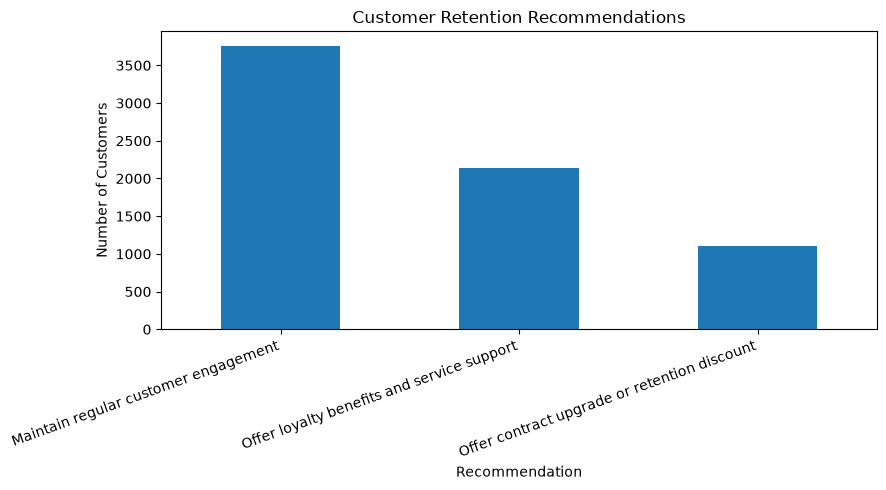

In [197]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

recommendation_summary.plot(kind='bar')

plt.title("Customer Retention Recommendations")
plt.xlabel("Recommendation")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20, ha='right')

plt.tight_layout()
plt.show()

In [198]:
final_report.to_csv(
    "final_customer_churn_retention_report.csv",
    index=False
)

print("Final customer churn retention report saved successfully!")
print("Total customers:", len(final_report))
print("Total columns:", len(final_report.columns))

Final customer churn retention report saved successfully!
Total customers: 7010
Total columns: 24


In [199]:
print("Final report columns:")
print(final_report.columns.tolist())

print("\nFinal report shape:")
print(final_report.shape)

Final report columns:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'Churn_Prediction', 'Churn_Probability', 'Risk_Category', 'Retention_Recommendation']

Final report shape:
(7010, 24)


In [200]:
import joblib

joblib.dump(final_accuracy_tree, "churn_model.pkl")
joblib.dump(preprocessor, "churn_preprocessor.pkl")

print("Model and preprocessor saved successfully!")

NameError: name 'final_accuracy_tree' is not defined

In [201]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
import joblib

# Load the cleaned dataset
df = pd.read_csv("telco_churn_cleaned.csv")

# Separate target and features
y = df["Churn"].map({"No": 0, "Yes": 1})
X = df.drop("Churn", axis=1)

# Identify categorical and numerical columns
categorical_columns = X.select_dtypes(include="object").columns
numerical_columns = X.select_dtypes(exclude="object").columns

# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            categorical_columns
        ),
        (
            "numerical",
            "passthrough",
            numerical_columns
        )
    ]
)

# Transform all customer data
X_processed = preprocessor.fit_transform(X)

# Train the Decision Tree model
final_accuracy_tree = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

final_accuracy_tree.fit(X_processed, y)

print("Model recreated successfully!")
print("Customers:", len(X))
print("Processed features:", X_processed.shape[1])

ImportError: DLL load failed while importing _partitioner: An Application Control policy has blocked this file.

In [202]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
import joblib

# Load cleaned dataset
df = pd.read_csv("telco_churn_cleaned.csv")

# Separate features and target
y = df["Churn"].map({"No": 0, "Yes": 1})
X = df.drop("Churn", axis=1)

# Identify columns
categorical_columns = X.select_dtypes(include="object").columns
numerical_columns = X.select_dtypes(exclude="object").columns

# Create preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_columns
        ),
        (
            "numerical",
            "passthrough",
            numerical_columns
        )
    ]
)

# Transform data
X_processed = preprocessor.fit_transform(X)

# Train Logistic Regression
final_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

final_model.fit(X_processed, y)

# Save model and preprocessor
joblib.dump(final_model, "churn_model.pkl")
joblib.dump(preprocessor, "churn_preprocessor.pkl")

print("Model and preprocessor saved successfully!")

C:\Users\vishn\AppData\Local\Temp\ipykernel_15164\2673497577.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X.select_dtypes(include="object").columns


Model and preprocessor saved successfully!


c:\Users\vishn\Desktop\python_learning\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
